# Notebook 10 — Training Model Task 3: Sentimen Aspek Hotel

**Task 3** mengklasifikasikan sentimen ulasan yang membahas aspek **Hotel**.

| | |
|---|---|
| **Input** | Ulasan yang membahas Hotel (`Hotel_label=1`) |
| **Label** | `Hotel_sentiment` → 0=Negatif, 1=Positif |
| **Task** | Binary Classification |
| **Train** | `df_train_Task3_Hotel.csv` (2,953 baris) |
| **Test** | `df_test_Task3_Hotel.csv` (328 baris) |
| **K-Fold** | StratifiedKFold (menjaga proporsi Pos:Neg) |

---

**8 Skenario:**

| # | Arsitektur | Embedding | Preprocessing |
|---|-----------|-----------|---------------|
| 1 | CNN | Word2Vec | Non-Stemming |
| 2 | CNN | Word2Vec | Stemming |
| 3 | CNN | FastText | Non-Stemming |
| 4 | CNN | FastText | Stemming |
| 5 | BiLSTM | Word2Vec | Non-Stemming |
| 6 | BiLSTM | Word2Vec | Stemming |
| 7 | BiLSTM | FastText | Non-Stemming |
| 8 | BiLSTM | FastText | Stemming |

## 1. Instalasi & Import Library

In [ ]:
# StratifiedKFold sudah termasuk dalam scikit-learn
# tidak perlu install tambahan
!pip install gensim scikit-learn openpyxl --quiet

import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from gensim.models import Word2Vec, FastText

# StratifiedKFold: menjaga proporsi kelas di setiap fold (untuk binary classification)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.metrics import AUC

tf.random.set_seed(42)
np.random.seed(42)

print('Library berhasil diimport.')
print(f'TensorFlow version: {tf.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.7 MB/s eta 0:00:00
Library berhasil diimport.
TensorFlow version: 2.19.0


## 2. Mount Google Drive & Konfigurasi Path

In [ ]:
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR   = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR   = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
EMBED_DIR   = BASE_DIR + 'Dataset/Dataset_WordEmbedding/'
OUTPUT_DIR  = BASE_DIR + 'Dataset/Dataset_Modelling/Task3_Hotel/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')


Mounted at /content/drive
Output dir: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/


## 3. Load Dataset, Tokenizer & Word Embedding


In [ ]:
# Load dataset Task 3 Hotel
df_train = pd.read_csv(SPLIT_DIR + 'df_train_Task3_Hotel.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task3_Hotel.csv')

print(f'Train : {len(df_train):,} baris')
print(f'Test  : {len(df_test):,} baris')
print(f'Kolom : {df_train.columns.tolist()}')
print(f'\nDistribusi label Hotel_sentiment (train):')
vc = df_train['Hotel_sentiment'].value_counts()
for k, v in vc.items():
    label = 'Positif' if k == 1 else 'Negatif'
    print(f'  {label} ({k}): {v:,} ({v/len(df_train)*100:.1f}%)')


Train : 2,953 baris
Test  : 328 baris
Kolom : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Hotel_sentiment']

Distribusi label Hotel_sentiment (train):
  Positif (1): 1,801 (61.0%)
  Negatif (0): 1,152 (39.0%)


In [ ]:
# Load tokenizer (yang sudah di fit dari data train)
with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'rb') as f:
    tokenizer_nonstem = pickle.load(f)
with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'rb') as f:
    tokenizer_stem = pickle.load(f)

print(f'Vocab tokenizer nonstem : {len(tokenizer_nonstem.word_index):,} kata')
print(f'Vocab tokenizer stem    : {len(tokenizer_stem.word_index):,} kata')

Vocab tokenizer nonstem : 5,545 kata
Vocab tokenizer stem    : 3,811 kata


In [ ]:
# Load word embedding models (yang dilatih dari semua data)
model_w2v_nonstem = Word2Vec.load(EMBED_DIR + 'word2vec_non_stemmed.model')
model_w2v_stem    = Word2Vec.load(EMBED_DIR + 'word2vec_stemmed.model')
model_ft_nonstem  = FastText.load(EMBED_DIR + 'fasttext_non_stemmed.model')
model_ft_stem     = FastText.load(EMBED_DIR + 'fasttext_stemmed.model')

print('Word embedding berhasil diload:')
print(f'  W2V NonStem vocab : {len(model_w2v_nonstem.wv):,}')
print(f'  W2V Stem vocab    : {len(model_w2v_stem.wv):,}')
print(f'  FT  NonStem vocab : {len(model_ft_nonstem.wv):,}')
print(f'  FT  Stem vocab    : {len(model_ft_stem.wv):,}')

Word embedding berhasil diload:
  W2V NonStem vocab : 3,401
  W2V Stem vocab    : 2,468
  FT  NonStem vocab : 3,401
  FT  Stem vocab    : 2,468


## 4. Fungsi-Fungsi Utama


In [ ]:
# ============================================================
# FUNGSI 1: Buat Embedding Matrix
# Mapping dari indeks tokenizer → vektor Word2Vec/FastText
# ============================================================
def buat_embedding_matrix(embed_model, tokenizer):
    vocab_size   = len(tokenizer.word_index) + 1
    vector_size  = embed_model.vector_size
    emb_matrix   = np.zeros((vocab_size, vector_size))
    oov_count    = 0

    for word, idx in tokenizer.word_index.items():
        try:
            emb_matrix[idx] = embed_model.wv[word]
        except KeyError:
            oov_count += 1

    print(f'  Vocab tokenizer : {vocab_size:,} kata')
    print(f'  OOV             : {oov_count:,} kata tidak ditemukan di embedding')
    print(f'  Shape matrix    : {emb_matrix.shape}')
    return emb_matrix

print('Fungsi buat_embedding_matrix siap.')

Fungsi buat_embedding_matrix siap.


In [ ]:
# ============================================================
# FUNGSI 2: Bangun Model CNN (TextCNN Kim 2014)
#
# Menerapkan L2 regularization untuk mencegah overfitting:
# → kernel_regularizer=l2(0.001) di Conv1D dan Dense
# → model tidak bisa terlalu menghafal data train
# → train loss tidak turun terlalu agresif ke ~0.01
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # L2 di Conv1D: mencegah filter terlalu spesifik ke data train
    conv3 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=3, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv4 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=4, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=5, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))

    concat = Concatenate()([conv3, conv4, conv5])
    x = Dropout(0.5)(concat)

    # L2 di Dense: mencegah neuron terlalu bergantung pada fitur tertentu
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_cnn siap (dengan L2=0.001).')


Fungsi bangun_model_cnn siap (dengan L2=0.001).


In [ ]:
# ============================================================
# FUNGSI 3: Bangun Model BiLSTM
#
# Menerapkan L2 regularization:
# → kernel_regularizer=l2(0.001) di Dense
# → BiLSTM sudah punya dropout internal (0.2) sehingga L2 hanya ditambah di Dense layer
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # BiLSTM sudah punya regularisasi internal: dropout=0.2 dan recurrent_dropout=0.2
    x = Bidirectional(LSTM(
        64,
        dropout           = 0.2,
        recurrent_dropout = 0.2
    ))(x)

    x = Dropout(0.5)(x)

    # L2 di Dense layer
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_bilstm siap (dengan L2=0.001).')


Fungsi bangun_model_bilstm siap (dengan L2=0.001).


In [ ]:
# ============================================================
# CEK ARSITEKTUR MODEL — Summary CNN & BiLSTM
# ============================================================

MAX_LENGTH = 100

# Pakai embedding matrix skenario 1 (nonstem) untuk preview
print('Membuat embedding matrix untuk preview...')
emb_preview = buat_embedding_matrix(model_w2v_nonstem, tokenizer_nonstem)

# ── Summary CNN ──
print('\n' + '='*65)
print('  ARSITEKTUR CNN')
print('='*65)
cnn_preview = bangun_model_cnn(emb_preview, MAX_LENGTH)
cnn_preview.summary()
del cnn_preview

# ── Summary BiLSTM ──
print('\n' + '='*65)
print('  ARSITEKTUR BiLSTM')
print('='*65)
bilstm_preview = bangun_model_bilstm(emb_preview, MAX_LENGTH)
bilstm_preview.summary()
del bilstm_preview

del emb_preview
print('\n✅ Arsitektur sudah dicek, siap training!')

Membuat embedding matrix untuk preview...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ARSITEKTUR CNN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    554,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 694,229 (2.65 MB)

 Trainable params: 139,629 (545.43 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 100)       │       554,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,401 (2.47 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 554,600 (2.12 MB)


✅ Arsitektur sudah dicek, siap training!


In [ ]:
# ============================================================
# FUNGSI 4: Hitung Metrik Binary Classification
#
# Berbeda dari Task 1 (multilabel):
# → accuracy biasa (bukan rata-rata per label)
# → tidak ada hamming loss, subset accuracy
# → AUC biasa (bukan multi_label=True)
# ============================================================
def hitung_metrik_binary(y_true, y_pred_prob):
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
    y_true = y_true.flatten()

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_prob.flatten())
    except:
        auc = 0.0

    return {
        'accuracy'        : acc,
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_macro'        : f1,
        'auc'             : auc,
    }

print('Fungsi hitung_metrik_binary siap.')

Fungsi hitung_metrik_binary siap.


In [ ]:
# ============================================================
# FUNGSI 5: Catat Resource (RAM & CPU)
# ============================================================
def catat_resource():
    proses     = psutil.Process(os.getpid())
    ram_mb     = proses.memory_info().rss / 1024 / 1024
    ram_total  = psutil.virtual_memory().total / 1024 / 1024
    ram_pct    = (ram_mb / ram_total) * 100
    cpu_pct    = psutil.cpu_percent(interval=1)
    return ram_mb, ram_pct, cpu_pct

print('Fungsi catat_resource siap.')

Fungsi catat_resource siap.


In [ ]:
# ============================================================
# FUNGSI 6: Plot Training History (Loss & Accuracy per Epoch)
# ============================================================
def plot_training_history(history_list, nama_skenario, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_idx, history in enumerate(history_list):
        label = f'Fold {fold_idx+1}'
        axes[0].plot(history['loss'],     linestyle='-',  label=f'{label} train')
        axes[0].plot(history['val_loss'], linestyle='--', label=f'{label} val')
        axes[1].plot(history['accuracy'],      linestyle='-',  label=f'{label} train')
        axes[1].plot(history['val_accuracy'],  linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Fungsi plot_training_history siap.')

Fungsi plot_training_history siap.


## 5. Persiapan Data


In [ ]:
MAX_LENGTH = 100
LABEL_COL  = 'Hotel_sentiment'

# Label binary
y_train = df_train[LABEL_COL].values
y_test  = df_test[LABEL_COL].values

# Tokenisasi NonStem
X_train_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_train['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_test['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# Tokenisasi Stem
X_train_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_train['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_test['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

print(f'X_train_nonstem : {X_train_nonstem.shape}')
print(f'X_train_stem    : {X_train_stem.shape}')
print(f'y_train         : {y_train.shape}')
print(f'y_test          : {y_test.shape}')

X_train_nonstem : (2953, 100)
X_train_stem    : (2953, 100)
y_train         : (2953,)
y_test          : (328,)


In [ ]:
skenario_list = [
    # ── CNN ──
    {'nama': 'Skenario1_CNN_W2V_NonStem',    'arsitektur': 'cnn',    'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario2_CNN_W2V_Stem',       'arsitektur': 'cnn',    'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario3_CNN_FT_NonStem',     'arsitektur': 'cnn',    'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario4_CNN_FT_Stem',        'arsitektur': 'cnn',    'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    # ── BiLSTM ──
    {'nama': 'Skenario5_BiLSTM_W2V_NonStem', 'arsitektur': 'bilstm', 'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario6_BiLSTM_W2V_Stem',    'arsitektur': 'bilstm', 'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario7_BiLSTM_FT_NonStem',  'arsitektur': 'bilstm', 'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario8_BiLSTM_FT_Stem',     'arsitektur': 'bilstm', 'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
]

print(f'Total skenario: {len(skenario_list)}')
for s in skenario_list:
    print(f"  {s['nama']}")


Total skenario: 8
  Skenario1_CNN_W2V_NonStem
  Skenario2_CNN_W2V_Stem
  Skenario3_CNN_FT_NonStem
  Skenario4_CNN_FT_Stem
  Skenario5_BiLSTM_W2V_NonStem
  Skenario6_BiLSTM_W2V_Stem
  Skenario7_BiLSTM_FT_NonStem
  Skenario8_BiLSTM_FT_Stem


## 7. Training 8 Skenario dengan Stratified K-Fold

**Alur per skenario:**
1. Buat embedding matrix
2. StratifiedKFold 5 fold → menjaga proporsi Positif:Negatif di tiap fold
3. Training + evaluasi per fold (tampilkan metrik, CM, ROC)
4. Simpan metrics, history, prediksi ke CSV
5. Simpan model fold terakhir (.h5)
6. Plot training history semua fold
7. Rekap rata-rata ± std dari 5 fold


In [ ]:
# ============================================================
# SETUP TRAINING
# ============================================================
K_FOLD     = 5
BATCH_SIZE = 32
MAX_EPOCH  = 20
rekap_semua = []
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=42)

# ============================================================
# CUSTOM CALLBACK — Catat Waktu per Epoch
# ============================================================
class WaktuCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.waktu_per_epoch = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.waktu_per_epoch.append(time.time() - self._epoch_start)

# ============================================================
# FUNGSI TRAINING 1 SKENARIO
# ============================================================
def jalankan_skenario(skenario):
    nama        = skenario['nama']
    arsitektur  = skenario['arsitektur']
    embed_model = skenario['embed_model']
    tokenizer   = skenario['tokenizer']
    X_train_s   = skenario['X_train']
    X_test_s    = skenario['X_test']
    skenario_dir = OUTPUT_DIR + nama + '/'
    os.makedirs(skenario_dir, exist_ok=True)

    # Skip kalau model sudah ada
    model_path = skenario_dir + 'model.h5'
    if os.path.exists(model_path):
        print(f'[SKIP] {nama} — model sudah ada')
        return

    print(f"\n{'='*65}")
    print(f'  Training: {nama}')
    print(f"{'='*65}")
    print('  Membuat embedding matrix...')
    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)

    metrics_semua_fold  = []
    history_semua_fold  = []
    prediksi_semua_fold = []

    for fold_ke, (train_idx, val_idx) in enumerate(
            skf.split(X_train_s, y_train), start=1):

        print(f'\n  ── Fold {fold_ke}/{K_FOLD} ──')

        early_stopping = EarlyStopping(
            monitor              = 'val_loss',
            patience             = 2,
            restore_best_weights = True,
            verbose              = 0
        )
        waktu_cb = WaktuCallback()  # ← callback waktu per epoch

        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]

        pos = y_fold_train.sum()
        neg = len(y_fold_train) - pos
        print(f'  Distribusi train: Pos={pos}, Neg={neg}')

        if arsitektur == 'cnn':
            model = bangun_model_cnn(embedding_matrix, MAX_LENGTH)
        else:
            model = bangun_model_bilstm(embedding_matrix, MAX_LENGTH)

        # ── Catat resource sebelum training ──
        ram_sebelum, ram_pct_sebelum, _ = catat_resource()  # ← 3 nilai
        waktu_train_mulai = time.time()

        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data = (X_fold_val, y_fold_val),
            epochs          = MAX_EPOCH,
            batch_size      = BATCH_SIZE,
            callbacks       = [early_stopping, waktu_cb],  # ← tambah waktu_cb
            verbose         = 1
        )

        waktu_training  = time.time() - waktu_train_mulai

        waktu_inf_mulai = time.time()
        y_pred_prob     = model.predict(X_fold_val, verbose=0)
        waktu_inference = time.time() - waktu_inf_mulai

        # ── Catat resource sesudah training ──
        ram_sesudah, ram_pct, cpu_pct = catat_resource()  # ← 3 nilai

        # ── Hitung waktu per epoch dan per step ──
        ep_selesai      = len(history.history['loss'])
        n_steps         = max(1, len(X_fold_train) // BATCH_SIZE)
        time_per_epoch  = round(
            sum(waktu_cb.waktu_per_epoch) / len(waktu_cb.waktu_per_epoch), 2
        ) if waktu_cb.waktu_per_epoch else 0
        time_per_step   = round(time_per_epoch / n_steps, 4)

        # ── Kumpulkan metrik ──
        metrik = hitung_metrik_binary(y_fold_val, y_pred_prob)
        metrik['fold']            = fold_ke
        metrik['waktu_training']  = round(waktu_training, 2)
        metrik['waktu_inference'] = round(waktu_inference, 4)
        metrik['time_per_epoch']  = time_per_epoch   # ← baru
        metrik['time_per_step']   = time_per_step    # ← baru
        metrik['ram_mb']          = round(ram_sesudah, 1)
        metrik['ram_pct']         = round(ram_pct, 2)  # ← baru
        metrik['cpu_pct']         = round(cpu_pct, 1)
        metrik['epoch_berhenti']  = ep_selesai
        metrics_semua_fold.append(metrik)

        df_history_fold = pd.DataFrame(history.history)
        df_history_fold['fold']  = fold_ke
        df_history_fold['epoch'] = range(1, len(df_history_fold)+1)
        history_semua_fold.append(df_history_fold)

        y_pred_biner = (y_pred_prob >= 0.5).astype(int).flatten()
        df_pred_fold = df_train.iloc[val_idx][
            ['id', 'review_non_stemmed', LABEL_COL]
        ].copy().reset_index(drop=True)
        df_pred_fold['pred_sentiment'] = y_pred_biner
        df_pred_fold['prob_positif']   = y_pred_prob.flatten().round(4)
        df_pred_fold['fold']           = fold_ke
        prediksi_semua_fold.append(df_pred_fold)

        # ── Print ringkasan fold ──
        print(f'\n  ┌─ Hasil Fold {fold_ke} ─────────────────────────────')
        print(f"  │  Epoch berhenti  : {metrik['epoch_berhenti']}")
        print(f"  │  Precision Macro : {metrik['precision_macro']:.4f}")
        print(f"  │  Recall Macro    : {metrik['recall_macro']:.4f}")
        print(f"  │  F1 Macro        : {metrik['f1_macro']:.4f}")
        print(f"  │  Accuracy        : {metrik['accuracy']:.4f}")
        print(f"  │  AUC             : {metrik['auc']:.4f}")
        print(f'  ├─ Resource ────────────────────────────────────')
        print(f"  │  Waktu Training  : {waktu_training:.2f} detik")
        print(f"  │  Waktu/Epoch     : {time_per_epoch:.2f} detik/epoch")
        print(f"  │  Waktu/Step      : {time_per_step:.4f} detik/step")
        print(f"  │  Waktu Inference : {waktu_inference:.4f} detik")
        print(f"  │  RAM Usage       : {ram_sesudah:.1f} MB ({ram_pct:.1f}%)")
        print(f"  └─ CPU Usage       : {cpu_pct:.1f} %")

        # ── Classification Report ──
        print(f'\n  Classification Report Fold {fold_ke}:')
        print(classification_report(
            y_fold_val, y_pred_biner,
            target_names=['Negatif', 'Positif'],
            zero_division=0
        ))

        # ── Confusion Matrix ──
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_fold_val, y_pred_biner)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                    xticklabels=['Negatif', 'Positif'],
                    yticklabels=['Negatif', 'Positif'])
        ax_cm.set_title(f'Confusion Matrix — {nama} Fold {fold_ke}',
                        fontweight='bold')
        ax_cm.set_xlabel('Prediksi')
        ax_cm.set_ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(skenario_dir + f'cm_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

        # ── ROC Curve ──
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        fpr, tpr, _ = roc_curve(y_fold_val, y_pred_prob.flatten())
        ax_roc.plot(fpr, tpr, color='#3498db',
                    label=f"AUC = {metrik['auc']:.3f}")
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve — {nama} Fold {fold_ke}',
                         fontweight='bold')
        ax_roc.legend(loc='lower right')
        ax_roc.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(skenario_dir + f'roc_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Selesai 5 fold — Simpan hasil ──
    pd.DataFrame(metrics_semua_fold).to_csv(
        skenario_dir + 'metrics_per_fold.csv', index=False)
    pd.concat(history_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'history_per_fold.csv', index=False)
    pd.concat(prediksi_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'predictions_all_folds.csv', index=False)

    # Simpan model fold terakhir
    model.save(model_path)
    print(f'\n  Model disimpan: {model_path}')

    # Plot training history
    plot_training_history(
        [h.to_dict('list') for h in history_semua_fold],
        nama,
        skenario_dir + 'training_history.png'
    )

    # ── Rekap rata-rata dan std ──
    df_metrics  = pd.DataFrame(metrics_semua_fold)
    metrik_cols = [
        'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'auc',
        'waktu_training', 'waktu_inference',
        'time_per_epoch', 'time_per_step',   # ← baru
        'ram_mb', 'ram_pct', 'cpu_pct',      # ← ram_pct baru
        'epoch_berhenti'
    ]
    rekap = {'skenario': nama, 'arsitektur': arsitektur}
    for col in metrik_cols:
        if col in df_metrics.columns:
            rekap[f'avg_{col}'] = round(df_metrics[col].mean(), 4)
            rekap[f'std_{col}'] = round(df_metrics[col].std(),  4)
    rekap_semua.append(rekap)

    # Simpan rekap langsung
    pd.DataFrame(rekap_semua).to_csv(
        OUTPUT_DIR + 'rekap_Task3_semua_skenario.csv', index=False)

    print(f"\n  ╔═ SELESAI: {nama}")
    print(f"  ║  avg Precision  : {rekap['avg_precision_macro']:.4f} ± {rekap['std_precision_macro']:.4f}")
    print(f"  ║  avg Recall     : {rekap['avg_recall_macro']:.4f} ± {rekap['std_recall_macro']:.4f}")
    print(f"  ║  avg F1 Macro   : {rekap['avg_f1_macro']:.4f} ± {rekap['std_f1_macro']:.4f}")
    print(f"  ║  avg Accuracy   : {rekap['avg_accuracy']:.4f} ± {rekap['std_accuracy']:.4f}")
    print(f"  ║  avg AUC        : {rekap['avg_auc']:.4f} ± {rekap['std_auc']:.4f}")
    print(f"  ║  avg RAM        : {rekap['avg_ram_mb']:.1f} MB ({rekap['avg_ram_pct']:.1f}%)")
    print(f"  ║  avg CPU        : {rekap['avg_cpu_pct']:.1f} %")
    print(f"  ║  avg Waktu      : {rekap['avg_waktu_training']:.2f} detik/fold")
    print(f"  ║  avg T/Epoch    : {rekap['avg_time_per_epoch']:.2f} detik/epoch")
    print(f"  ║  avg T/Step     : {rekap['avg_time_per_step']:.4f} detik/step")
    print(f"  ╚══════════════════════════════════════════════════")

print('Setup selesai.')

Setup selesai.



  Training: Skenario1_CNN_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7921 - auc: 0.8709 - loss: 0.8267 - val_accuracy: 0.8985 - val_auc: 0.9750 - val_loss: 0.6249
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9001 - auc: 0.9589 - loss: 0.6027 - val_accuracy: 0.9255 - val_auc: 0.9840 - val_loss: 0.5321
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9373 - auc: 0.9784 - loss: 0.4914 - val_accuracy: 0.9459 - val_auc: 0.9865 - val_loss: 0.4436
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9509 - auc: 0.9861 - loss: 0.4197 - val_accuracy: 0.9391 - val_auc: 0.9878 - val_loss: 0.4270
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9581 - auc: 0.9899 - loss: 0.3669 - val_accuracy: 

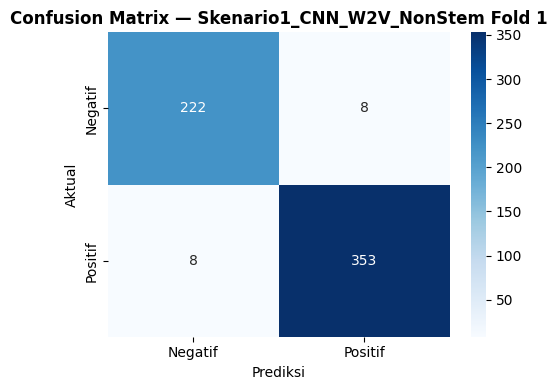

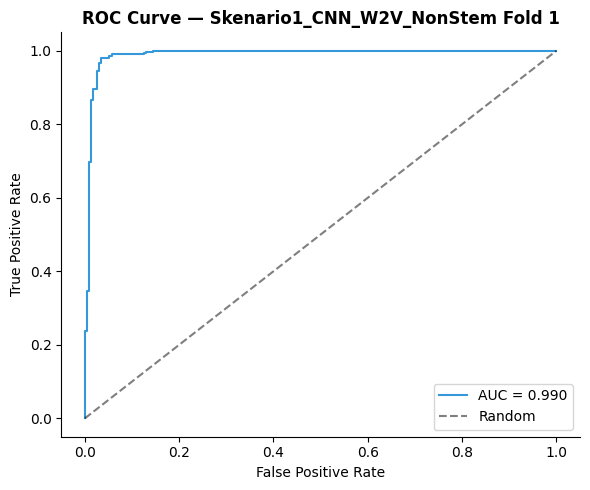


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.7739 - auc: 0.8601 - loss: 0.8440 - val_accuracy: 0.8697 - val_auc: 0.9545 - val_loss: 0.6514
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9039 - auc: 0.9597 - loss: 0.6030 - val_accuracy: 0.9239 - val_auc: 0.9781 - val_loss: 0.5215
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9331 - auc: 0.9777 - loss: 0.4982 - val_accuracy: 0.9391 - val_auc: 0.9853 - val_loss: 0.4517
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9522 - auc: 0.9844 - loss: 0.4297 - val_accuracy: 0.9492 - val_auc: 0.9887 - val_loss: 0.4035
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.9585 - auc: 0.9906 - loss: 0.3721 - val_accuracy: 0.9509 - val_auc: 0.9911 - val_loss: 0.3618
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9678 - auc: 0.9926 - loss: 0.3283 - val_accuracy: 0.9577 - val_auc: 0.9927 - val_lo

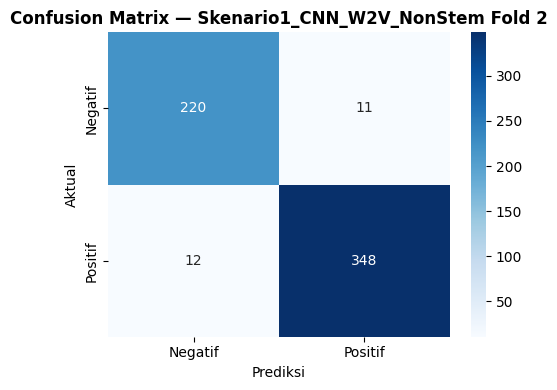

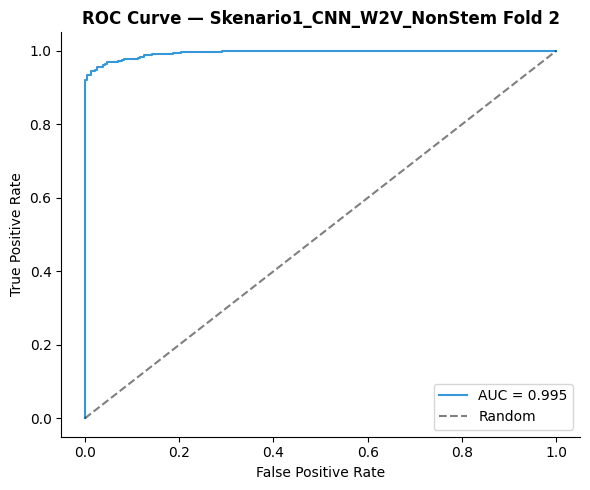


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.8002 - auc: 0.8828 - loss: 0.8063 - val_accuracy: 0.9171 - val_auc: 0.9738 - val_loss: 0.5798
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9153 - auc: 0.9680 - loss: 0.5756 - val_accuracy: 0.9357 - val_auc: 0.9843 - val_loss: 0.4943
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9420 - auc: 0.9832 - loss: 0.4721 - val_accuracy: 0.9425 - val_auc: 0.9880 - val_loss: 0.4407
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9539 - auc: 0.9886 - loss: 0.4099 - val_accuracy: 0.9526 - val_auc: 0.9904 - val_loss: 0.3938
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.9644 - auc: 0.9919 - loss: 0.3605 - val_accuracy: 0.9594 - val_auc: 0.9905 - val_loss: 0.3538
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9687 - auc: 0.9938 - loss: 0.3196 - val_accuracy: 0.9594 - val_auc: 0.9915 - val_los

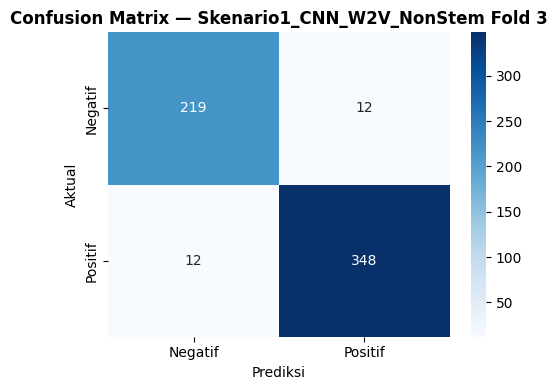

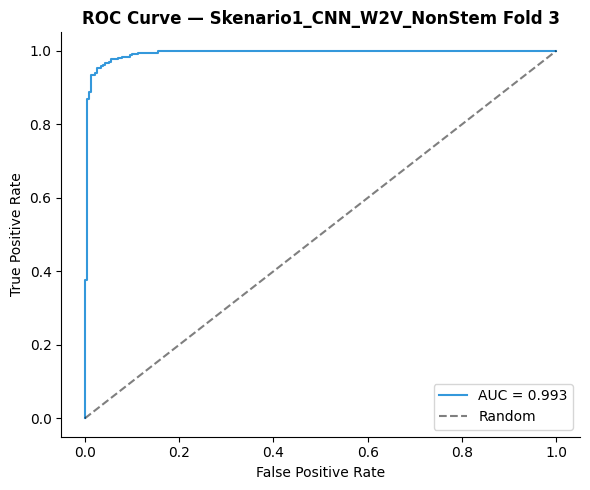


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7990 - auc: 0.8829 - loss: 0.8042 - val_accuracy: 0.9254 - val_auc: 0.9743 - val_loss: 0.5702
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9022 - auc: 0.9613 - loss: 0.5929 - val_accuracy: 0.9559 - val_auc: 0.9866 - val_loss: 0.4672
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9319 - auc: 0.9768 - loss: 0.4995 - val_accuracy: 0.9627 - val_auc: 0.9906 - val_loss: 0.4040
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9496 - auc: 0.9870 - loss: 0.4231 - val_accuracy: 0.9627 - val_auc: 0.9920 - val_loss: 0.3614
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9530 - auc: 0.9892 - loss: 0.3807 - val_accuracy: 0.9678 - val_auc: 0.9925 - val_loss: 0.3287
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9678 - auc: 0.9930 - loss: 0.3262 - val_accuracy: 0.9712 - val_auc: 0.9930 - val_los

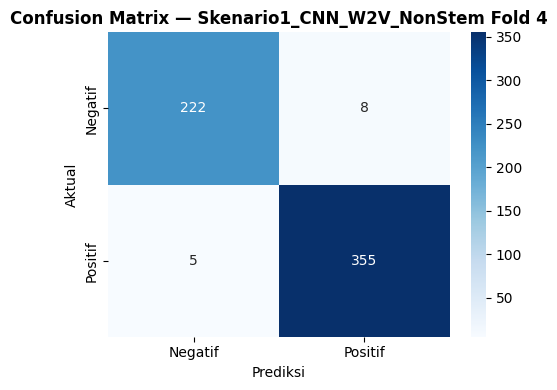

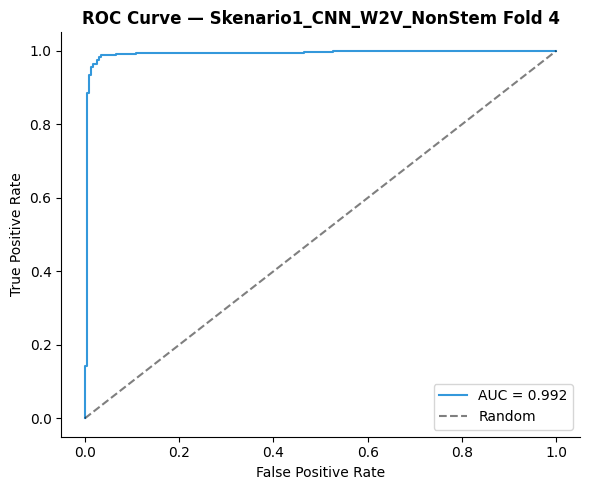


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.7859 - auc: 0.8764 - loss: 0.8195 - val_accuracy: 0.8864 - val_auc: 0.9639 - val_loss: 0.6353
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9200 - auc: 0.9689 - loss: 0.5741 - val_accuracy: 0.9051 - val_auc: 0.9784 - val_loss: 0.5631
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9433 - auc: 0.9828 - loss: 0.4762 - val_accuracy: 0.9339 - val_auc: 0.9828 - val_loss: 0.4696
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9534 - auc: 0.9890 - loss: 0.4084 - val_accuracy: 0.9441 - val_auc: 0.9852 - val_loss: 0.4158
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9661 - auc: 0.9903 - loss: 0.3616 - val_accuracy: 0.9458 - val_auc: 0.9863 - val_loss: 0.3821
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9704 - auc: 0.9935 - loss: 0.3175 - val_accuracy: 0.9339 - val_auc: 0.9860 - val_los

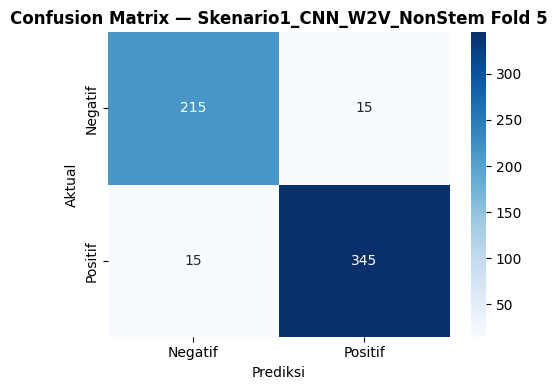

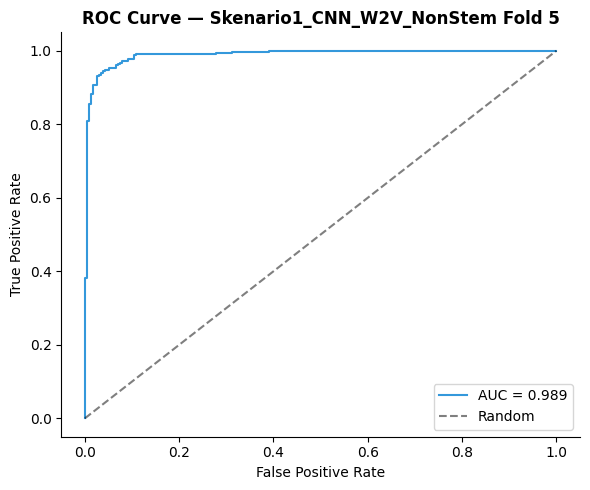


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario1_CNN_W2V_NonStem/model.h5


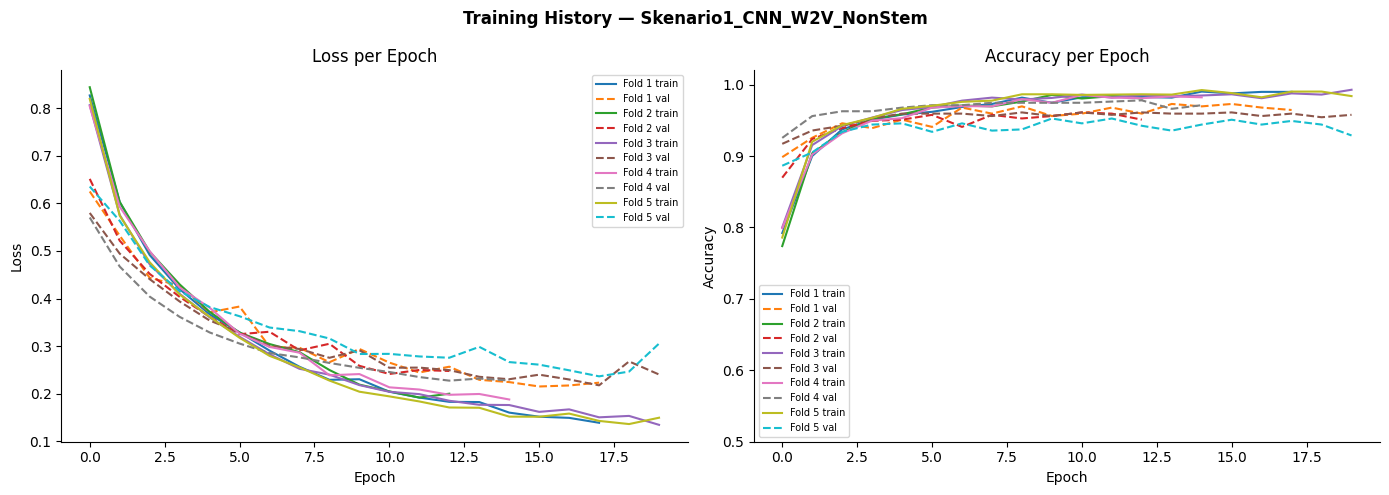


  ╔═ SELESAI: Skenario1_CNN_W2V_NonStem
  ║  avg Precision  : 0.9624 ± 0.0124
  ║  avg Recall     : 0.9621 ± 0.0117
  ║  avg F1 Macro   : 0.9623 ± 0.0120
  ║  avg Accuracy   : 0.9641 ± 0.0115
  ║  avg AUC        : 0.9917 ± 0.0023
  ║  avg RAM        : 2606.7 MB (20.1%)
  ║  avg CPU        : 20.7 %
  ║  avg Waktu      : 92.94 detik/fold
  ║  avg T/Epoch    : 5.40 detik/epoch
  ║  avg T/Step     : 0.0740 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 1 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[0])


  Training: Skenario2_CNN_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.7947 - auc: 0.8684 - loss: 0.8256 - val_accuracy: 0.9154 - val_auc: 0.9725 - val_loss: 0.5948
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9047 - auc: 0.9630 - loss: 0.5883 - val_accuracy: 0.9306 - val_auc: 0.9827 - val_loss: 0.5123
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9378 - auc: 0.9802 - loss: 0.4800 - val_accuracy: 0.9340 - val_auc: 0.9860 - val_loss: 0.4610
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9522 - auc: 0.9843 - loss: 0.4209 - val_accuracy: 0.9391 - val_auc: 0.9868 - val_loss: 0.4183
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9589 - auc: 0.9905 - loss: 0.3650 - val_accuracy: 0.93

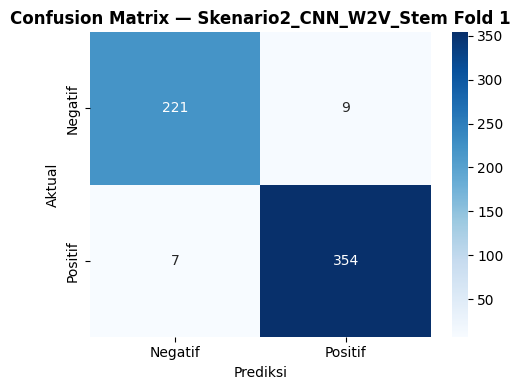

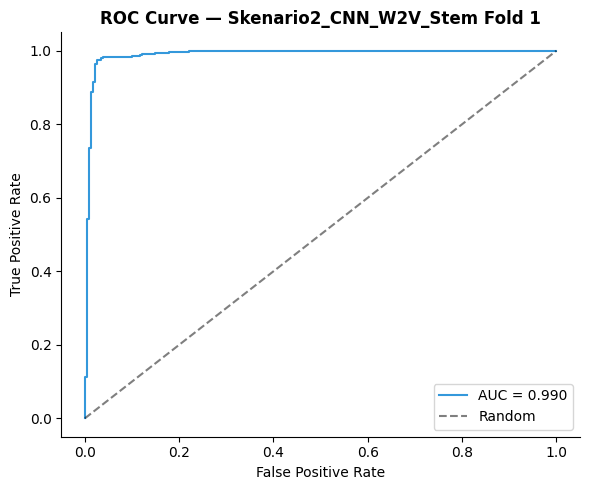


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7934 - auc: 0.8612 - loss: 0.8395 - val_accuracy: 0.8765 - val_auc: 0.9574 - val_loss: 0.6453
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9026 - auc: 0.9586 - loss: 0.6021 - val_accuracy: 0.9086 - val_auc: 0.9764 - val_loss: 0.5279
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9340 - auc: 0.9781 - loss: 0.4941 - val_accuracy: 0.9323 - val_auc: 0.9837 - val_loss: 0.4602
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9543 - auc: 0.9857 - loss: 0.4206 - val_accuracy: 0.9425 - val_auc: 0.9875 - val_loss: 0.4125
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9623 - auc: 0.9908 - loss: 0.3643 - val_accuracy: 0.9357 - val_auc: 0.9889 - val_loss: 0.3742
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9666 - auc: 0.9925 - loss: 0.3231 - val_accuracy: 0.9459 - val_auc: 0.9901 - val_los

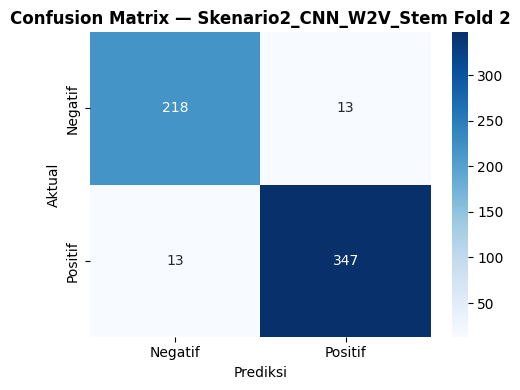

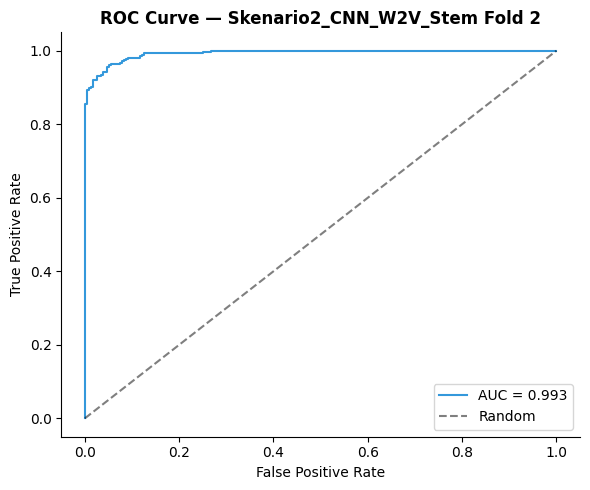


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7739 - auc: 0.8671 - loss: 0.8275 - val_accuracy: 0.9019 - val_auc: 0.9680 - val_loss: 0.5959
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9035 - auc: 0.9623 - loss: 0.5847 - val_accuracy: 0.9239 - val_auc: 0.9811 - val_loss: 0.5060
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9344 - auc: 0.9799 - loss: 0.4821 - val_accuracy: 0.9425 - val_auc: 0.9859 - val_loss: 0.4301
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9530 - auc: 0.9868 - loss: 0.4112 - val_accuracy: 0.9408 - val_auc: 0.9884 - val_loss: 0.4034
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9623 - auc: 0.9918 - loss: 0.3523 - val_accuracy: 0.9492 - val_auc: 0.9889 - val_loss: 0.3626
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9704 - auc: 0.9941 - loss: 0.3091 - val_accuracy: 0.9425 - val_auc: 0.9894 - val_los

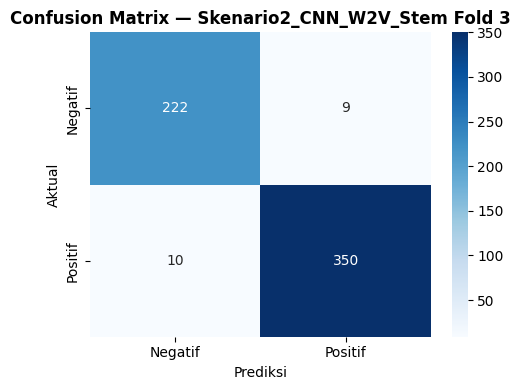

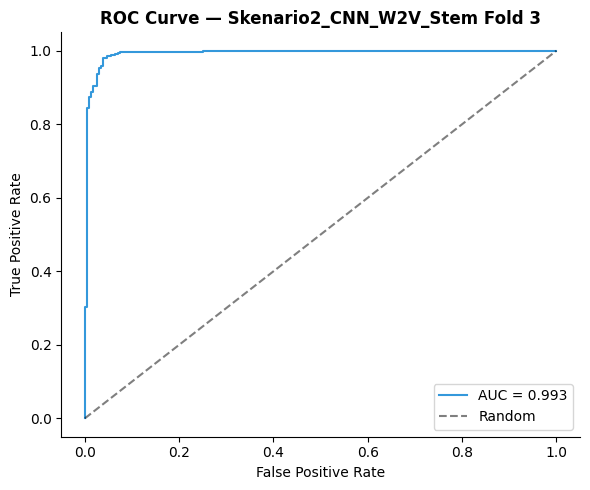


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.7812 - auc: 0.8506 - loss: 0.8493 - val_accuracy: 0.9068 - val_auc: 0.9717 - val_loss: 0.5867
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9061 - auc: 0.9622 - loss: 0.5892 - val_accuracy: 0.9390 - val_auc: 0.9855 - val_loss: 0.4772
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9319 - auc: 0.9760 - loss: 0.5005 - val_accuracy: 0.9593 - val_auc: 0.9894 - val_loss: 0.4118
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9471 - auc: 0.9835 - loss: 0.4301 - val_accuracy: 0.9644 - val_auc: 0.9914 - val_loss: 0.3701
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9581 - auc: 0.9890 - loss: 0.3739 - val_accuracy: 0.9678 - val_auc: 0.9921 - val_loss: 0.3360
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9661 - auc: 0.9936 - loss: 0.3218 - val_accuracy: 0.9712 - val_auc: 0.9920 - val_los

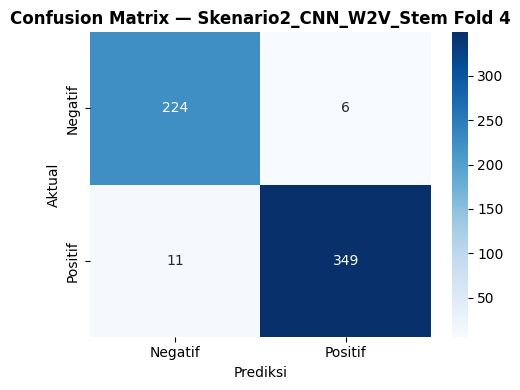

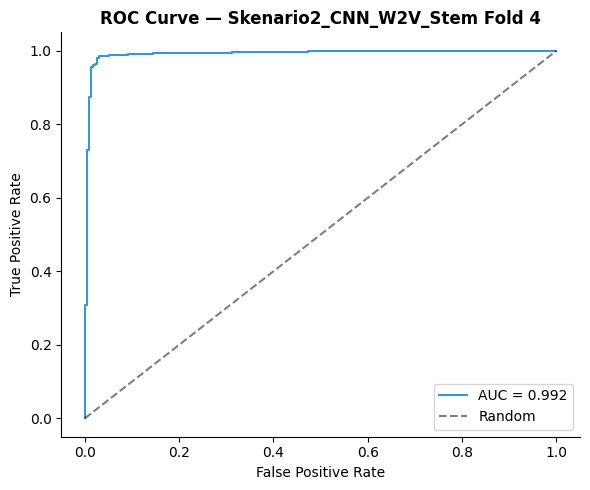


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.7656 - auc: 0.8311 - loss: 0.8774 - val_accuracy: 0.8661 - val_auc: 0.9592 - val_loss: 0.6573
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8997 - auc: 0.9572 - loss: 0.6057 - val_accuracy: 0.9203 - val_auc: 0.9752 - val_loss: 0.5214
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9348 - auc: 0.9787 - loss: 0.4821 - val_accuracy: 0.9288 - val_auc: 0.9828 - val_loss: 0.4527
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9479 - auc: 0.9851 - loss: 0.4165 - val_accuracy: 0.9356 - val_auc: 0.9844 - val_loss: 0.4209
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9611 - auc: 0.9915 - loss: 0.3510 - val_accuracy: 0.9458 - val_auc: 0.9857 - val_loss: 0.3715
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9733 - auc: 0.9941 - loss: 0.3000 - val_accuracy: 0.9424 - val_auc: 0.9869 - val_lo

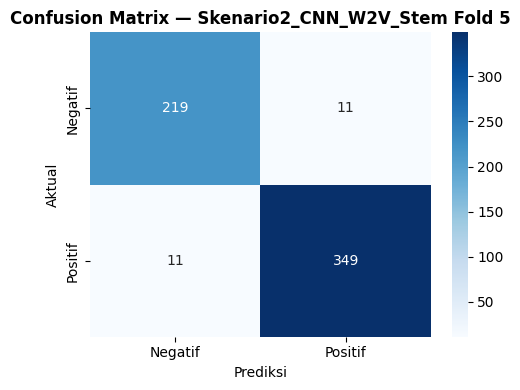

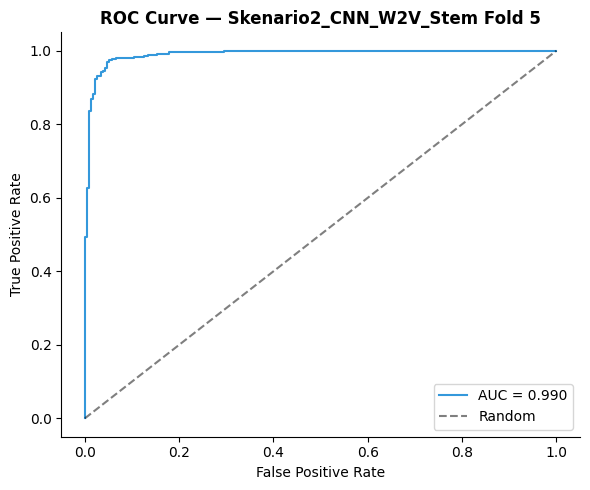


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario2_CNN_W2V_Stem/model.h5


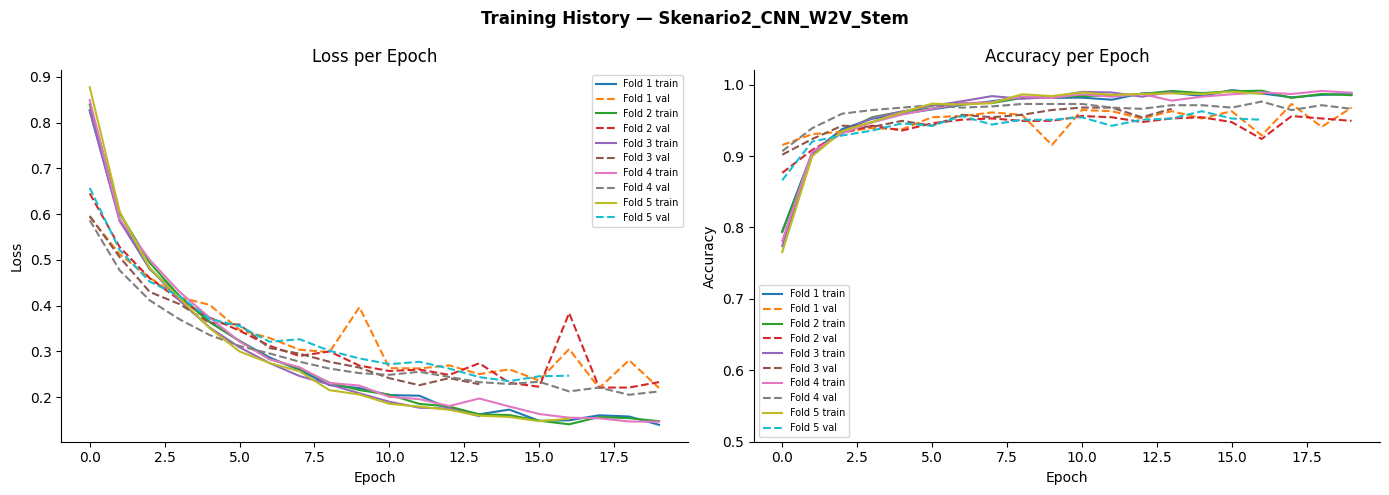


  ╔═ SELESAI: Skenario2_CNN_W2V_Stem
  ║  avg Precision  : 0.9642 ± 0.0071
  ║  avg Recall     : 0.9647 ± 0.0075
  ║  avg F1 Macro   : 0.9644 ± 0.0072
  ║  avg Accuracy   : 0.9661 ± 0.0069
  ║  avg AUC        : 0.9917 ± 0.0015
  ║  avg RAM        : 2693.6 MB (20.8%)
  ║  avg CPU        : 9.8 %
  ║  avg Waktu      : 92.91 detik/fold
  ║  avg T/Epoch    : 5.11 detik/epoch
  ║  avg T/Step     : 0.0700 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 2 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[1])


  Training: Skenario3_CNN_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7777 - auc: 0.8544 - loss: 0.8486 - val_accuracy: 0.9205 - val_auc: 0.9734 - val_loss: 0.5920
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8882 - auc: 0.9569 - loss: 0.6102 - val_accuracy: 0.9323 - val_auc: 0.9836 - val_loss: 0.5112
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9225 - auc: 0.9766 - loss: 0.5054 - val_accuracy: 0.9425 - val_auc: 0.9867 - val_loss: 0.4518
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9450 - auc: 0.9841 - loss: 0.4343 - val_accuracy: 0.9340 - val_auc: 0.9876 - val_loss: 0.4270
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9581 - auc: 0.9887 - loss: 0.3781 - val_accuracy: 0.9408

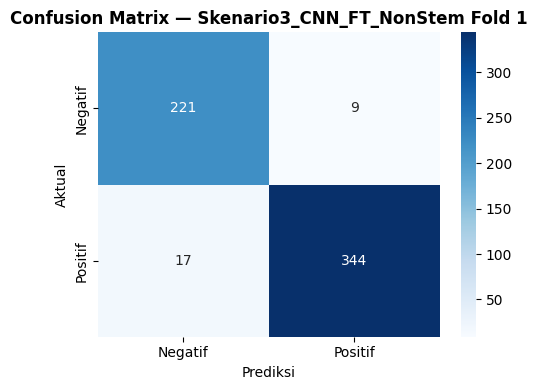

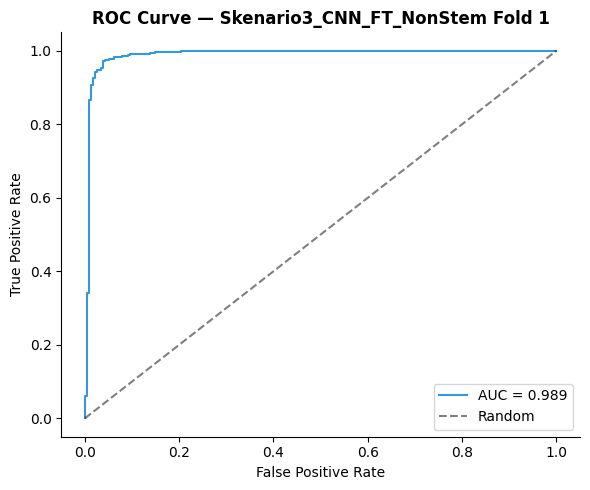


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.7722 - auc: 0.8530 - loss: 0.8439 - val_accuracy: 0.8426 - val_auc: 0.9462 - val_loss: 0.6726
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8959 - auc: 0.9535 - loss: 0.6037 - val_accuracy: 0.9002 - val_auc: 0.9746 - val_loss: 0.5314
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9306 - auc: 0.9756 - loss: 0.4898 - val_accuracy: 0.9340 - val_auc: 0.9847 - val_loss: 0.4398
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9475 - auc: 0.9835 - loss: 0.4165 - val_accuracy: 0.9374 - val_auc: 0.9884 - val_loss: 0.3871
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9568 - auc: 0.9882 - loss: 0.3614 - val_accuracy: 0.9239 - val_auc: 0.9887 - val_loss: 0.4222
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9619 - auc: 0.9902 - loss: 0.3275 - val_accuracy: 0.9475 - val_auc: 0.9903 - val_los

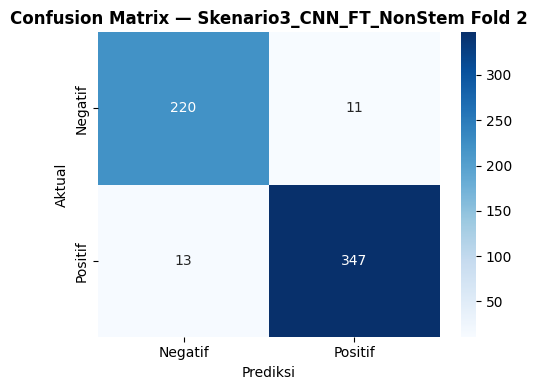

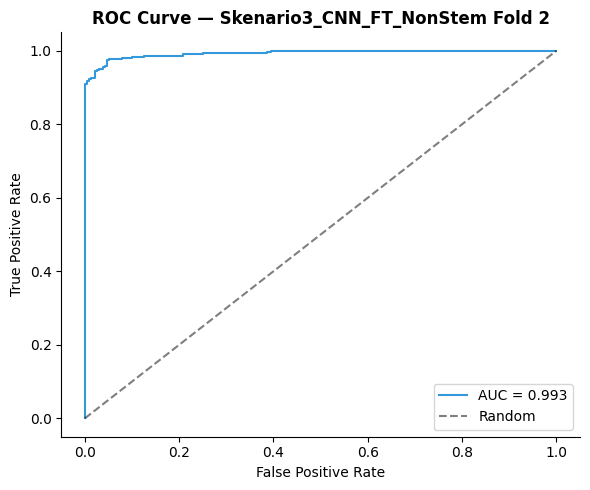


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.7786 - auc: 0.8592 - loss: 0.8395 - val_accuracy: 0.9052 - val_auc: 0.9655 - val_loss: 0.6036
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8992 - auc: 0.9558 - loss: 0.6033 - val_accuracy: 0.9255 - val_auc: 0.9817 - val_loss: 0.4965
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9289 - auc: 0.9766 - loss: 0.4923 - val_accuracy: 0.9357 - val_auc: 0.9860 - val_loss: 0.4421
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9483 - auc: 0.9844 - loss: 0.4186 - val_accuracy: 0.9374 - val_auc: 0.9884 - val_loss: 0.4066
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9568 - auc: 0.9886 - loss: 0.3694 - val_accuracy: 0.9526 - val_auc: 0.9895 - val_loss: 0.3628
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9602 - auc: 0.9911 - loss: 0.3318 - val_accuracy: 0.9645 - val_auc: 0.9900 - val_los

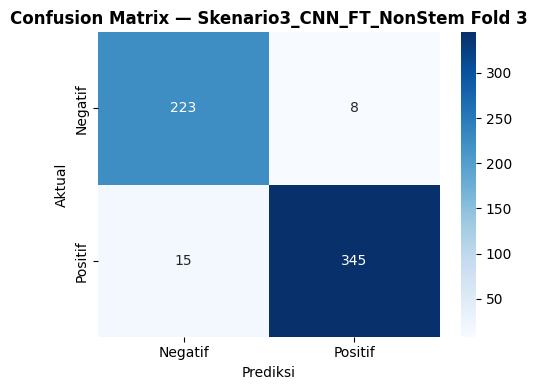

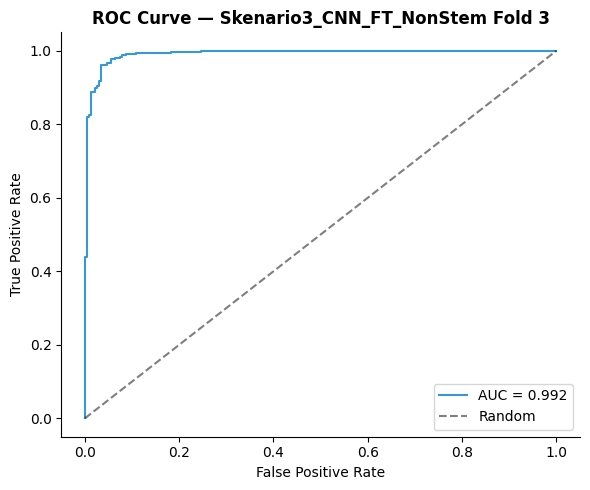


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7829 - auc: 0.8614 - loss: 0.8367 - val_accuracy: 0.9153 - val_auc: 0.9670 - val_loss: 0.5974
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.8908 - auc: 0.9553 - loss: 0.6035 - val_accuracy: 0.9424 - val_auc: 0.9827 - val_loss: 0.4781
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9276 - auc: 0.9738 - loss: 0.4992 - val_accuracy: 0.9610 - val_auc: 0.9873 - val_loss: 0.4095
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9450 - auc: 0.9813 - loss: 0.4332 - val_accuracy: 0.9627 - val_auc: 0.9895 - val_loss: 0.3606
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9501 - auc: 0.9867 - loss: 0.3805 - val_accuracy: 0.9559 - val_auc: 0.9908 - val_loss: 0.3479
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9640 - auc: 0.9910 - loss: 0.3333 - val_accuracy: 0.9729 - val_auc: 0.9908 - val_los

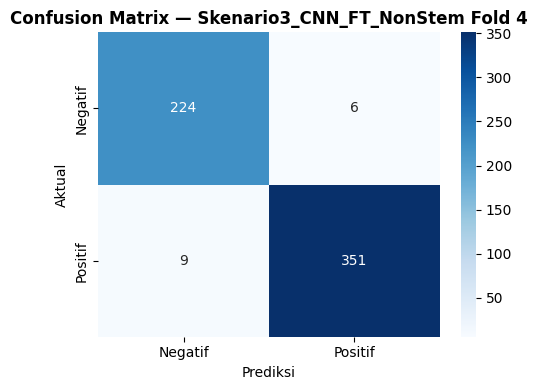

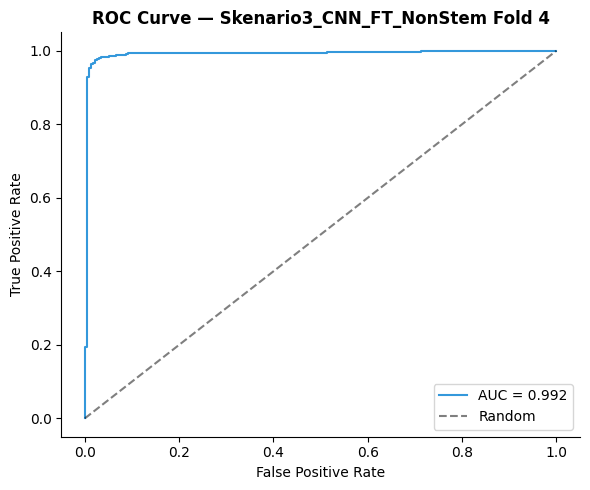


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.7761 - auc: 0.8556 - loss: 0.8448 - val_accuracy: 0.8780 - val_auc: 0.9590 - val_loss: 0.6400
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8993 - auc: 0.9558 - loss: 0.6066 - val_accuracy: 0.8949 - val_auc: 0.9740 - val_loss: 0.5692
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9259 - auc: 0.9750 - loss: 0.5035 - val_accuracy: 0.9017 - val_auc: 0.9805 - val_loss: 0.5159
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9412 - auc: 0.9830 - loss: 0.4341 - val_accuracy: 0.9068 - val_auc: 0.9829 - val_loss: 0.4760
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9556 - auc: 0.9893 - loss: 0.3728 - val_accuracy: 0.9237 - val_auc: 0.9845 - val_loss: 0.4400
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9632 - auc: 0.9924 - loss: 0.3288 - val_accuracy: 0.9356 - val_auc: 0.9854 - val_los

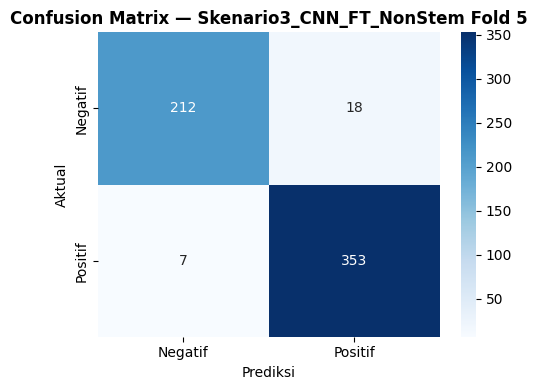

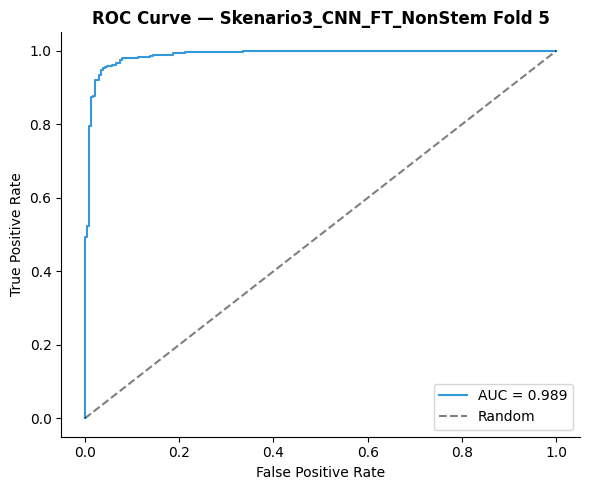


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario3_CNN_FT_NonStem/model.h5


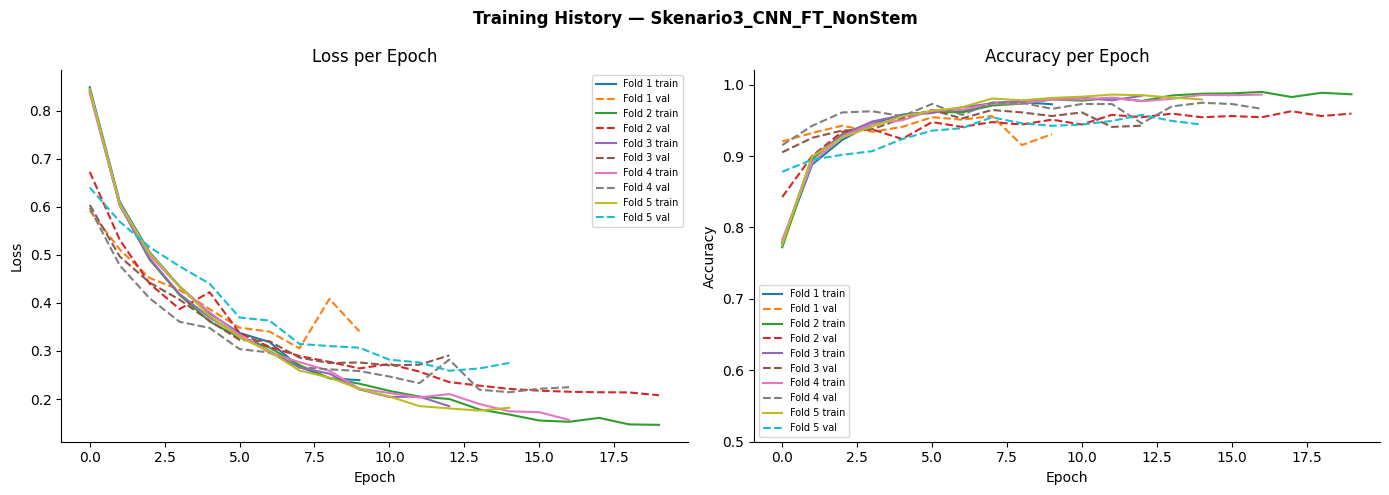


  ╔═ SELESAI: Skenario3_CNN_FT_NonStem
  ║  avg Precision  : 0.9595 ± 0.0077
  ║  avg Recall     : 0.9605 ± 0.0087
  ║  avg F1 Macro   : 0.9598 ± 0.0078
  ║  avg Accuracy   : 0.9617 ± 0.0074
  ║  avg AUC        : 0.9910 ± 0.0018
  ║  avg RAM        : 2833.1 MB (21.8%)
  ║  avg CPU        : 13.0 %
  ║  avg Waktu      : 79.89 detik/fold
  ║  avg T/Epoch    : 5.27 detik/epoch
  ║  avg T/Step     : 0.0722 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 3 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[2])


  Training: Skenario4_CNN_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.7735 - auc: 0.8610 - loss: 0.8367 - val_accuracy: 0.9171 - val_auc: 0.9731 - val_loss: 0.5964
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8954 - auc: 0.9564 - loss: 0.6055 - val_accuracy: 0.9255 - val_auc: 0.9826 - val_loss: 0.5081
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9280 - auc: 0.9759 - loss: 0.4994 - val_accuracy: 0.9205 - val_auc: 0.9849 - val_loss: 0.4771
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9433 - auc: 0.9826 - loss: 0.4372 - val_accuracy: 0.9171 - val_auc: 0.9862 - val_loss: 0.4471
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9543 - auc: 0.9866 - loss: 0.3848 - val_accuracy: 0.9239 - 

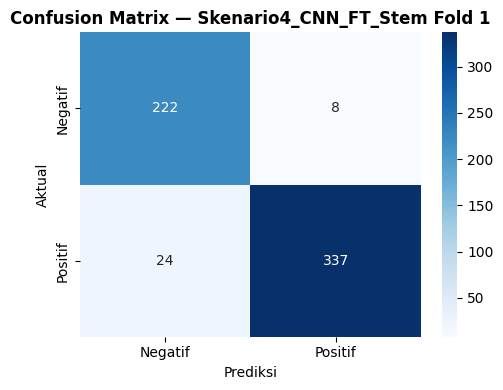

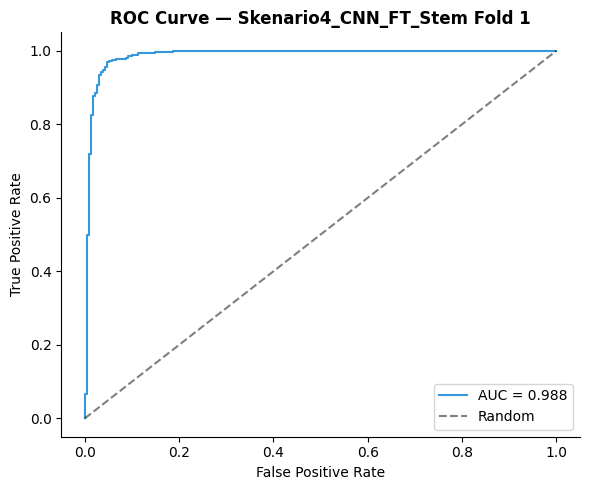


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.7782 - auc: 0.8514 - loss: 0.8458 - val_accuracy: 0.8511 - val_auc: 0.9489 - val_loss: 0.6562
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8967 - auc: 0.9546 - loss: 0.6060 - val_accuracy: 0.8883 - val_auc: 0.9705 - val_loss: 0.5554
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9213 - auc: 0.9707 - loss: 0.5111 - val_accuracy: 0.9289 - val_auc: 0.9793 - val_loss: 0.4602
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9399 - auc: 0.9809 - loss: 0.4350 - val_accuracy: 0.9408 - val_auc: 0.9842 - val_loss: 0.4156
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9475 - auc: 0.9843 - loss: 0.3866 - val_accuracy: 0.9306 - val_auc: 0.9862 - val_loss: 0.3989
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9577 - auc: 0.9876 - loss: 0.3476 - val_accuracy: 0.9442 - val_auc: 0.9886 - val_los

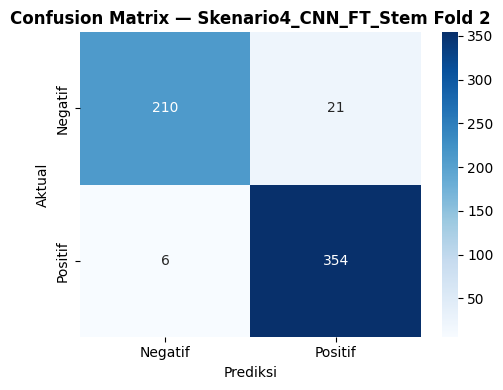

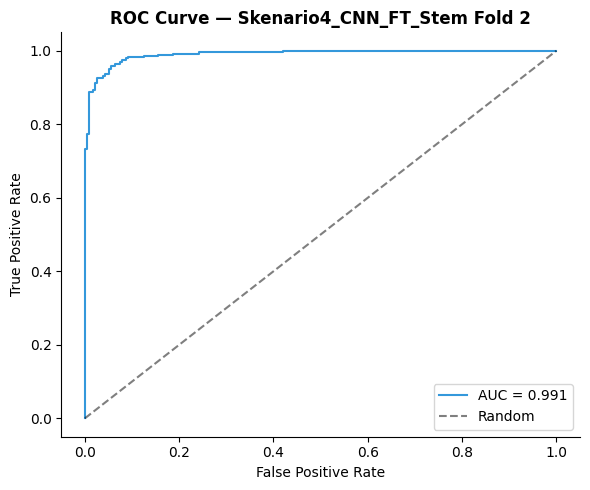


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7870 - auc: 0.8665 - loss: 0.8328 - val_accuracy: 0.8951 - val_auc: 0.9664 - val_loss: 0.6040
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.8992 - auc: 0.9599 - loss: 0.5938 - val_accuracy: 0.9340 - val_auc: 0.9807 - val_loss: 0.4989
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9318 - auc: 0.9770 - loss: 0.4907 - val_accuracy: 0.9442 - val_auc: 0.9843 - val_loss: 0.4365
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9479 - auc: 0.9846 - loss: 0.4140 - val_accuracy: 0.9492 - val_auc: 0.9874 - val_loss: 0.3913
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9564 - auc: 0.9886 - loss: 0.3666 - val_accuracy: 0.9560 - val_auc: 0.9885 - val_loss: 0.3520
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9636 - auc: 0.9904 - loss: 0.3278 - val_accuracy: 0.9492 - val_auc: 0.9891 - val_los

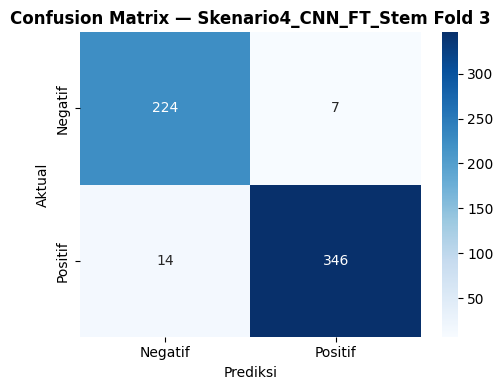

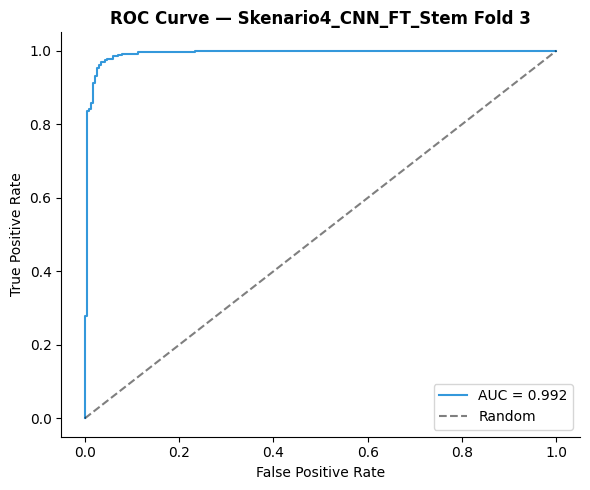


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.7643 - auc: 0.8355 - loss: 0.8648 - val_accuracy: 0.8966 - val_auc: 0.9648 - val_loss: 0.6014
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8904 - auc: 0.9543 - loss: 0.5962 - val_accuracy: 0.9390 - val_auc: 0.9832 - val_loss: 0.4704
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9213 - auc: 0.9735 - loss: 0.4885 - val_accuracy: 0.9542 - val_auc: 0.9879 - val_loss: 0.4033
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9353 - auc: 0.9802 - loss: 0.4246 - val_accuracy: 0.9644 - val_auc: 0.9903 - val_loss: 0.3519
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9518 - auc: 0.9873 - loss: 0.3635 - val_accuracy: 0.9678 - val_auc: 0.9918 - val_loss: 0.3164
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9577 - auc: 0.9885 - loss: 0.3296 - val_accuracy: 0.9695 - val_auc: 0.9925 - val_los

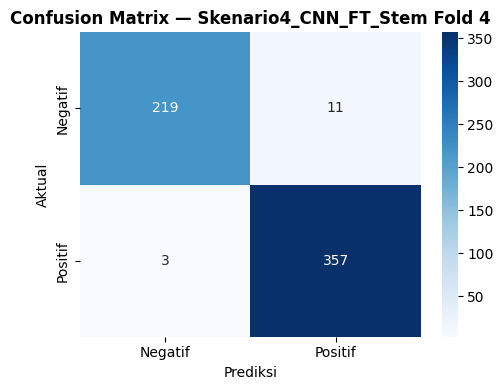

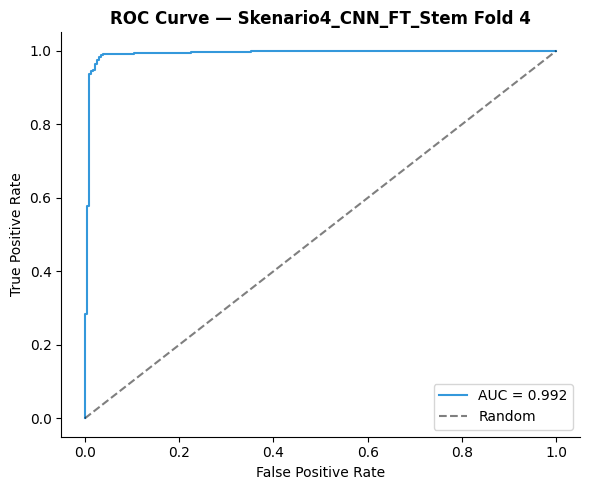


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.7664 - auc: 0.8528 - loss: 0.8454 - val_accuracy: 0.8780 - val_auc: 0.9585 - val_loss: 0.6346
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8997 - auc: 0.9559 - loss: 0.5941 - val_accuracy: 0.9186 - val_auc: 0.9734 - val_loss: 0.5286
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9369 - auc: 0.9792 - loss: 0.4666 - val_accuracy: 0.9305 - val_auc: 0.9803 - val_loss: 0.4484
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9479 - auc: 0.9847 - loss: 0.4037 - val_accuracy: 0.9373 - val_auc: 0.9820 - val_loss: 0.4041
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9611 - auc: 0.9885 - loss: 0.3520 - val_accuracy: 0.9153 - val_auc: 0.9836 - val_loss: 0.4271
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9666 - auc: 0.9931 - loss: 0.3019 - val_accuracy: 0.9356 - val_auc: 0.9835 - val_lo

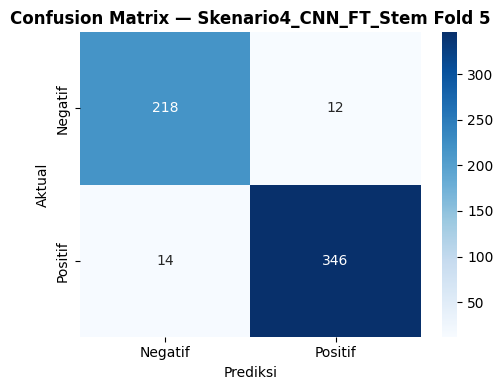

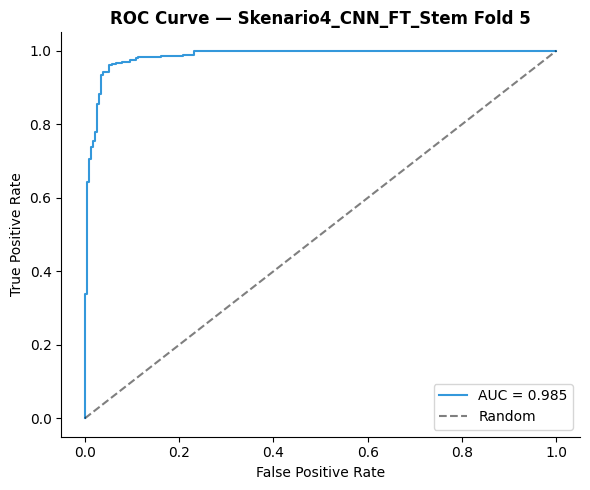


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario4_CNN_FT_Stem/model.h5


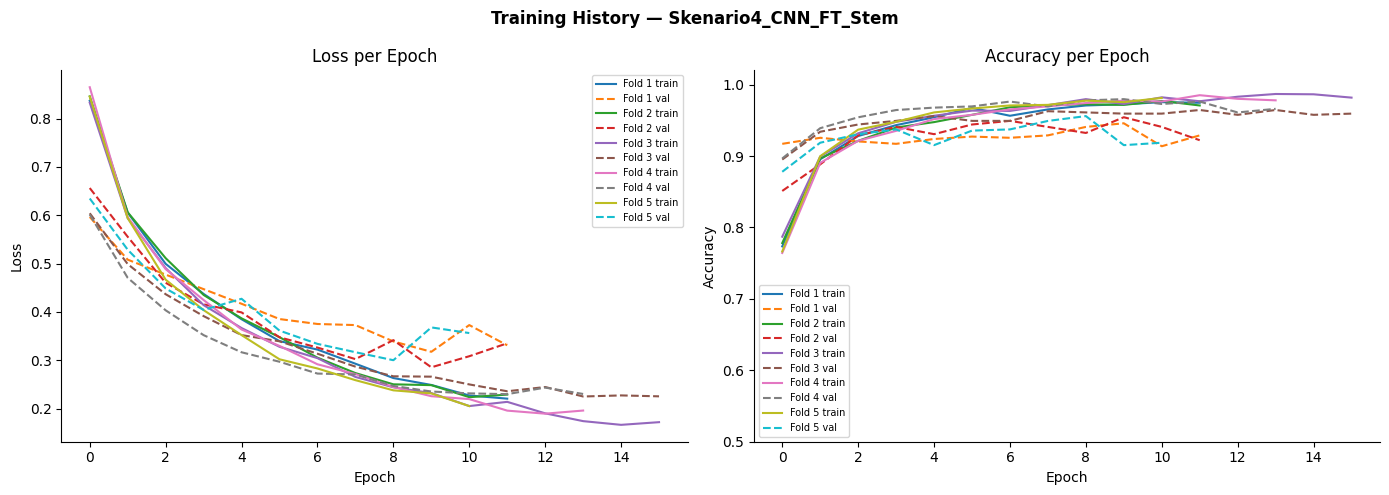


  ╔═ SELESAI: Skenario4_CNN_FT_Stem
  ║  avg Precision  : 0.9580 ± 0.0140
  ║  avg Recall     : 0.9575 ± 0.0109
  ║  avg F1 Macro   : 0.9573 ± 0.0120
  ║  avg Accuracy   : 0.9594 ± 0.0115
  ║  avg AUC        : 0.9897 ± 0.0030
  ║  avg RAM        : 2920.2 MB (22.5%)
  ║  avg CPU        : 11.3 %
  ║  avg Waktu      : 68.96 detik/fold
  ║  avg T/Epoch    : 5.29 detik/epoch
  ║  avg T/Step     : 0.0725 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 4 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[3])


  Training: Skenario5_BiLSTM_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.7557 - auc: 0.8563 - loss: 0.5342 - val_accuracy: 0.8680 - val_auc: 0.9637 - val_loss: 0.3725
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step - accuracy: 0.8802 - auc: 0.9361 - loss: 0.3540 - val_accuracy: 0.9188 - val_auc: 0.9705 - val_loss: 0.2660
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.8963 - auc: 0.9548 - loss: 0.3014 - val_accuracy: 0.9171 - val_auc: 0.9706 - val_loss: 0.2429
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 255ms/step - accuracy: 0.9073 - auc: 0.9626 - loss: 0.2712 - val_accuracy: 0.9272 - val_auc: 0.9756 - val_loss: 0.2167
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.9174 - auc: 0.9676 - loss: 0.2474 - va

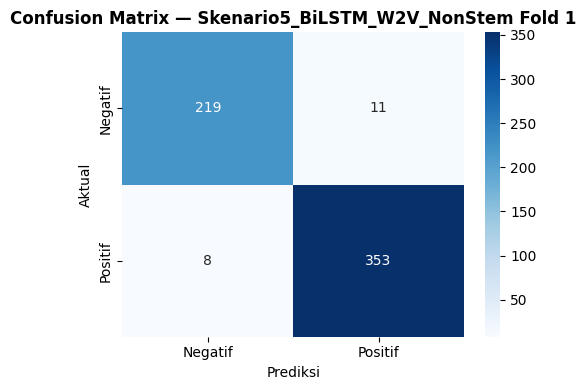

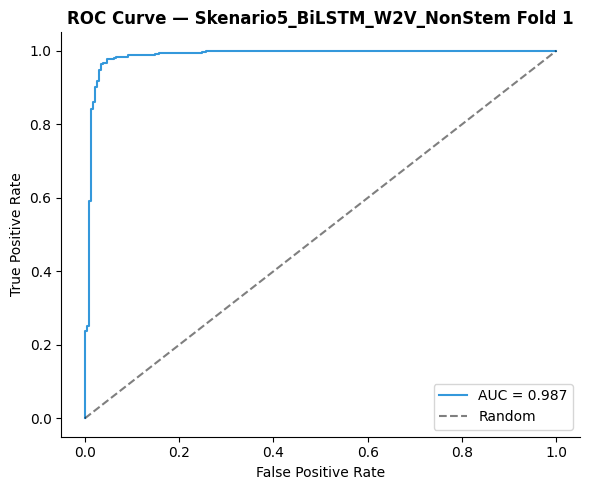


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0.7638 - auc: 0.8509 - loss: 0.5397 - val_accuracy: 0.8697 - val_auc: 0.9417 - val_loss: 0.3576
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.8836 - auc: 0.9404 - loss: 0.3425 - val_accuracy: 0.8883 - val_auc: 0.9591 - val_loss: 0.3016
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.9005 - auc: 0.9535 - loss: 0.2998 - val_accuracy: 0.9036 - val_auc: 0.9684 - val_loss: 0.2629
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9107 - auc: 0.9619 - loss: 0.2686 - val_accuracy: 0.9052 - val_auc: 0.9700 - val_loss: 0.2516
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 235ms/step - accuracy: 0.9225 - auc: 0.9665 - loss: 0.2482 - val_accuracy: 0.9205 - val_auc: 0.9765 - val_loss: 0.2228
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9179 - auc: 0.9686 - loss: 0.2406 - val_accuracy: 0.9222 - val_auc: 0.97

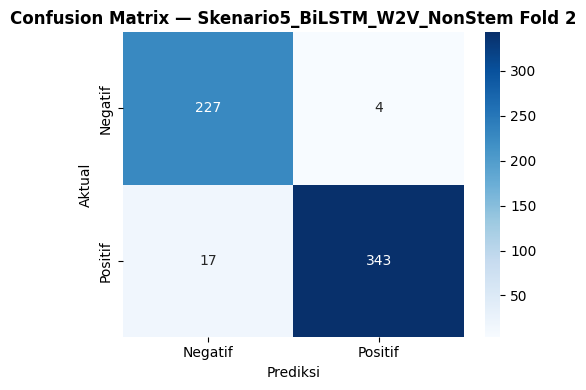

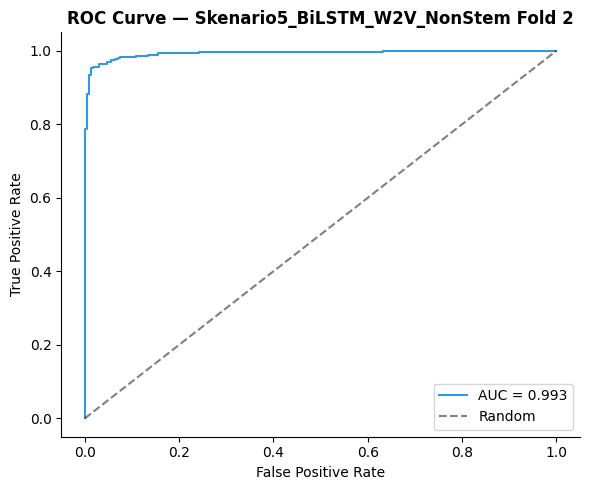


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 254ms/step - accuracy: 0.7710 - auc: 0.8498 - loss: 0.5509 - val_accuracy: 0.8799 - val_auc: 0.9569 - val_loss: 0.3345
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 245ms/step - accuracy: 0.8853 - auc: 0.9419 - loss: 0.3448 - val_accuracy: 0.9120 - val_auc: 0.9677 - val_loss: 0.2630
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.9052 - auc: 0.9521 - loss: 0.3026 - val_accuracy: 0.9255 - val_auc: 0.9727 - val_loss: 0.2378
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - accuracy: 0.9124 - auc: 0.9613 - loss: 0.2706 - val_accuracy: 0.9222 - val_auc: 0.9745 - val_loss: 0.2300
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.9153 - auc: 0.9646 - loss: 0.2574 - val_accuracy: 0.9323 - val_auc: 0.9789 - val_loss: 0.2051
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.9213 - auc: 0.9720 - loss: 0.2269 - val_accuracy: 0.9442 - val_auc: 0.98

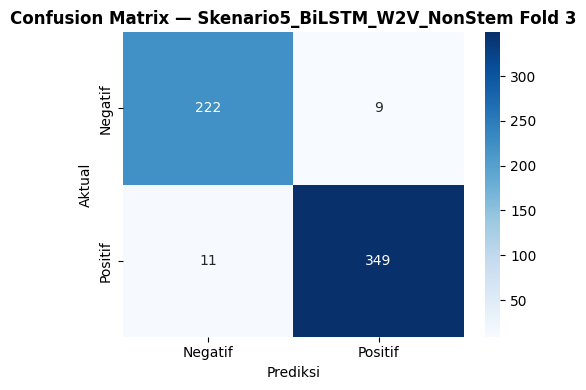

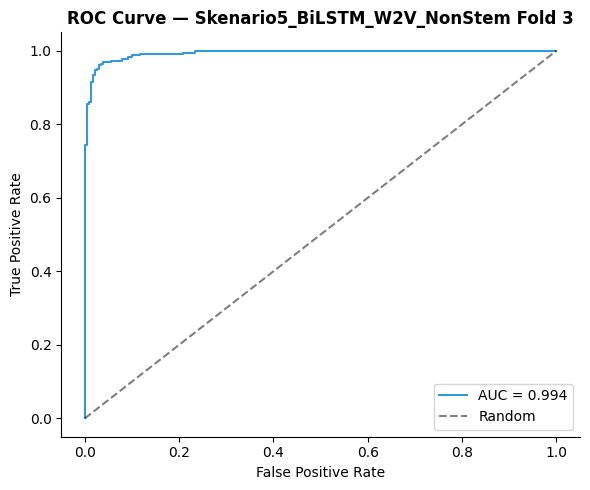


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 262ms/step - accuracy: 0.7486 - auc: 0.8410 - loss: 0.5538 - val_accuracy: 0.8966 - val_auc: 0.9617 - val_loss: 0.3025
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.8769 - auc: 0.9358 - loss: 0.3577 - val_accuracy: 0.9136 - val_auc: 0.9720 - val_loss: 0.2691
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 273ms/step - accuracy: 0.8815 - auc: 0.9452 - loss: 0.3308 - val_accuracy: 0.9220 - val_auc: 0.9779 - val_loss: 0.2273
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.9086 - auc: 0.9609 - loss: 0.2777 - val_accuracy: 0.9339 - val_auc: 0.9810 - val_loss: 0.2058
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.9132 - auc: 0.9671 - loss: 0.2553 - val_accuracy: 0.9576 - val_auc: 0.9839 - val_loss: 0.1803
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9242 - auc: 0.9699 - loss: 0.2379 - val_accuracy: 0.9576 - val_auc: 0.98

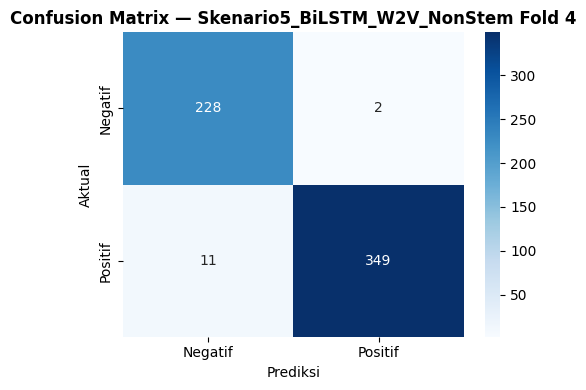

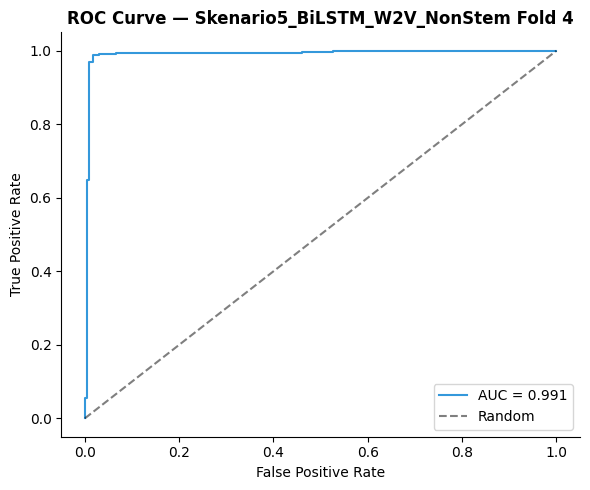


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 257ms/step - accuracy: 0.7715 - auc: 0.8581 - loss: 0.5299 - val_accuracy: 0.8712 - val_auc: 0.9486 - val_loss: 0.3659
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 268ms/step - accuracy: 0.8862 - auc: 0.9455 - loss: 0.3357 - val_accuracy: 0.8966 - val_auc: 0.9622 - val_loss: 0.2953
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.8976 - auc: 0.9507 - loss: 0.3100 - val_accuracy: 0.9102 - val_auc: 0.9680 - val_loss: 0.2619
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.9052 - auc: 0.9640 - loss: 0.2680 - val_accuracy: 0.9102 - val_auc: 0.9728 - val_loss: 0.2529
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 250ms/step - accuracy: 0.9128 - auc: 0.9647 - loss: 0.2590 - val_accuracy: 0.9186 - val_auc: 0.9769 - val_loss: 0.2191
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 254ms/step - accuracy: 0.9264 - auc: 0.9717 - loss: 0.2324 - val_accuracy: 0.9220 - val_auc: 0.97

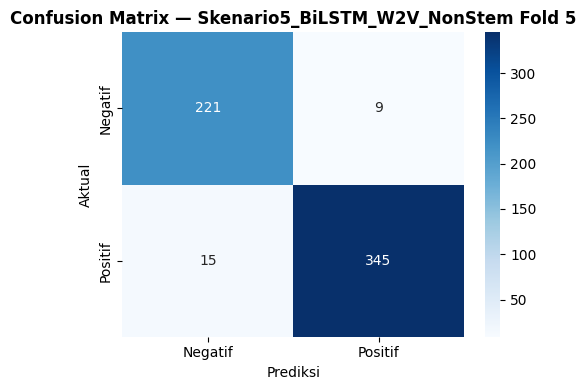

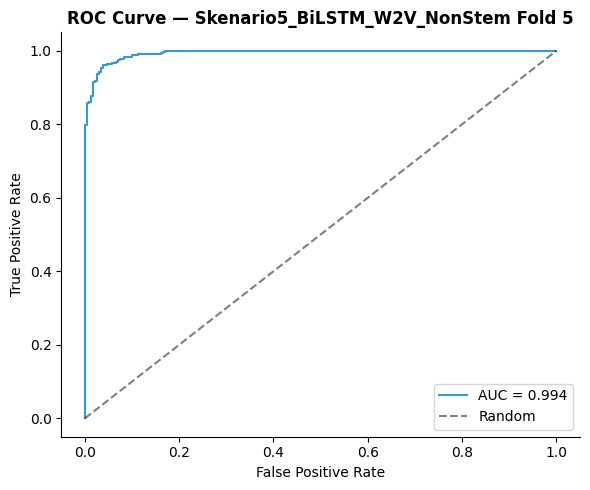


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario5_BiLSTM_W2V_NonStem/model.h5


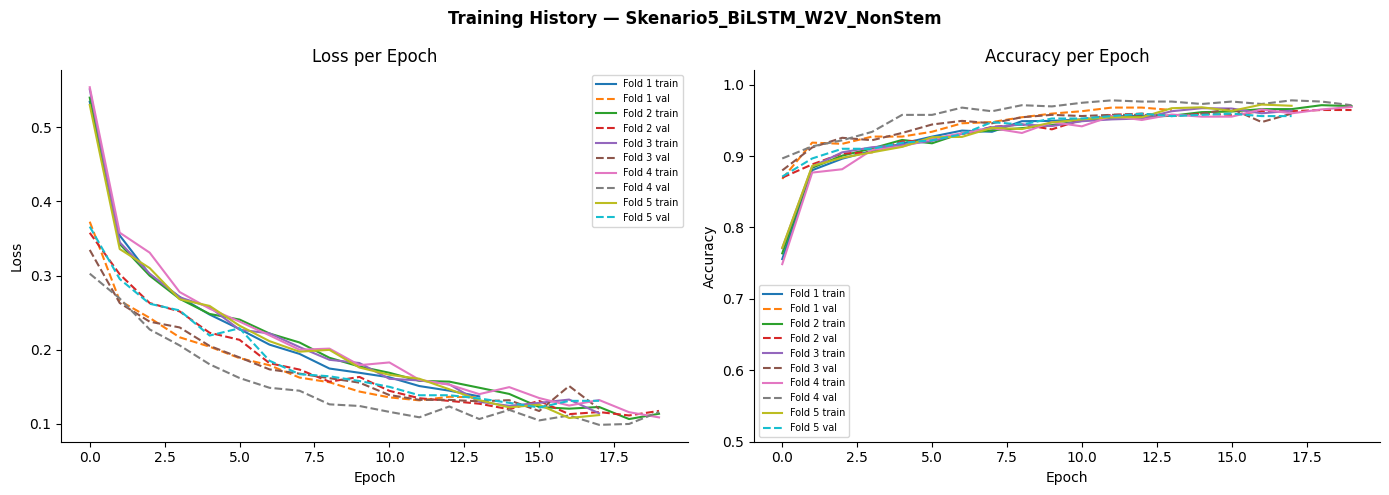


  ╔═ SELESAI: Skenario5_BiLSTM_W2V_NonStem
  ║  avg Precision  : 0.9640 ± 0.0072
  ║  avg Recall     : 0.9676 ± 0.0077
  ║  avg F1 Macro   : 0.9656 ± 0.0071
  ║  avg Accuracy   : 0.9672 ± 0.0068
  ║  avg AUC        : 0.9918 ± 0.0029
  ║  avg RAM        : 3200.4 MB (24.7%)
  ║  avg CPU        : 2.2 %
  ║  avg Waktu      : 355.90 detik/fold
  ║  avg T/Epoch    : 19.70 detik/epoch
  ║  avg T/Step     : 0.2698 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 5 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[4])


  Training: Skenario6_BiLSTM_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.7481 - auc: 0.8323 - loss: 0.5631 - val_accuracy: 0.8866 - val_auc: 0.9602 - val_loss: 0.3328
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.8865 - auc: 0.9409 - loss: 0.3445 - val_accuracy: 0.9069 - val_auc: 0.9676 - val_loss: 0.2836
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.8878 - auc: 0.9474 - loss: 0.3190 - val_accuracy: 0.9239 - val_auc: 0.9690 - val_loss: 0.2485
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.8942 - auc: 0.9561 - loss: 0.2909 - val_accuracy: 0.9272 - val_auc: 0.9713 - val_loss: 0.2320
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.9107 - auc: 0.9666 - loss: 0.2546 - val_a

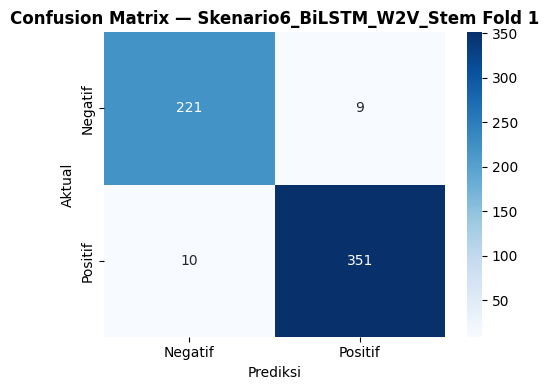

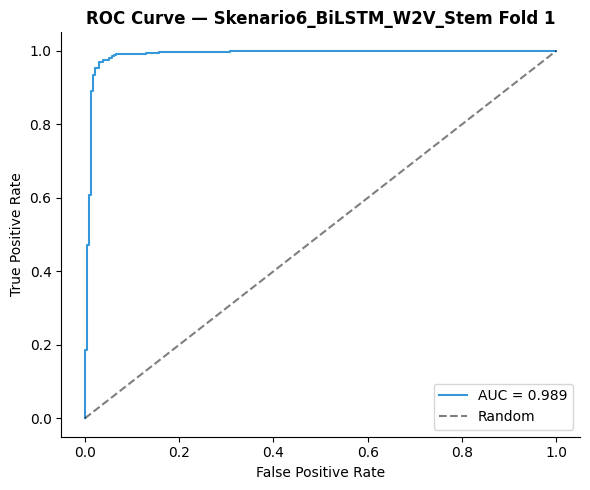


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.7743 - auc: 0.8616 - loss: 0.5257 - val_accuracy: 0.8528 - val_auc: 0.9469 - val_loss: 0.3594
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 242ms/step - accuracy: 0.8916 - auc: 0.9474 - loss: 0.3296 - val_accuracy: 0.8816 - val_auc: 0.9588 - val_loss: 0.3027
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.8997 - auc: 0.9531 - loss: 0.3025 - val_accuracy: 0.8968 - val_auc: 0.9665 - val_loss: 0.2717
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9157 - auc: 0.9635 - loss: 0.2689 - val_accuracy: 0.9019 - val_auc: 0.9717 - val_loss: 0.2538
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.9221 - auc: 0.9651 - loss: 0.2560 - val_accuracy: 0.9188 - val_auc: 0.9761 - val_loss: 0.2268
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.9153 - auc: 0.9678 - loss: 0.2466 - val_accuracy: 0.9222 - val_auc: 0.97

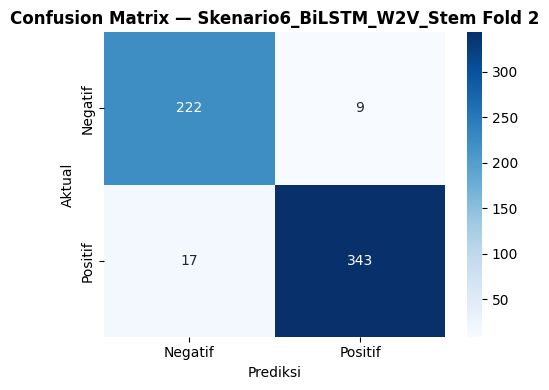

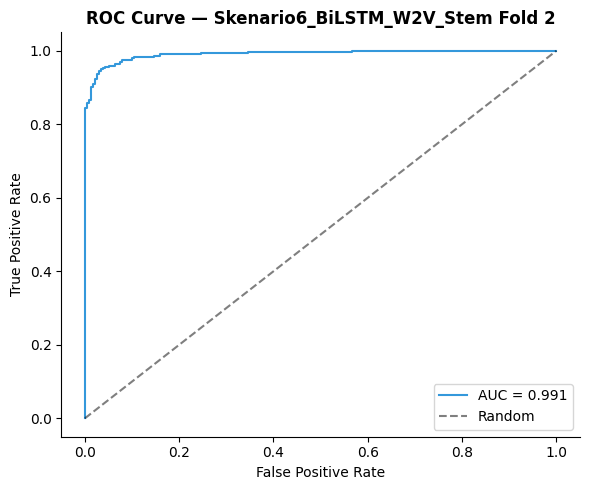


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 255ms/step - accuracy: 0.7544 - auc: 0.8419 - loss: 0.5525 - val_accuracy: 0.8934 - val_auc: 0.9597 - val_loss: 0.3110
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.8831 - auc: 0.9364 - loss: 0.3550 - val_accuracy: 0.8968 - val_auc: 0.9649 - val_loss: 0.2907
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.8971 - auc: 0.9513 - loss: 0.3100 - val_accuracy: 0.9205 - val_auc: 0.9680 - val_loss: 0.2560
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.8988 - auc: 0.9549 - loss: 0.2900 - val_accuracy: 0.9239 - val_auc: 0.9725 - val_loss: 0.2537
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.9086 - auc: 0.9615 - loss: 0.2679 - val_accuracy: 0.9255 - val_auc: 0.9758 - val_loss: 0.2239
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.9213 - auc: 0.9678 - loss: 0.2435 - val_accuracy: 0.9306 - val_auc: 0.97

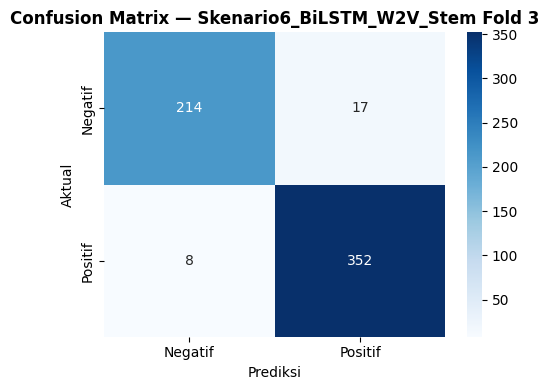

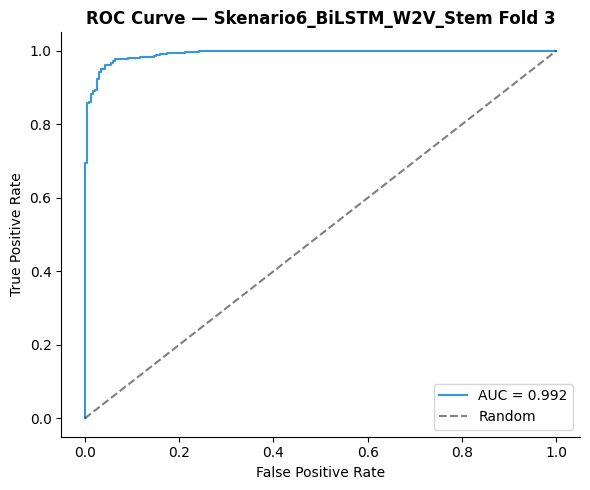


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.7469 - auc: 0.8409 - loss: 0.5558 - val_accuracy: 0.8966 - val_auc: 0.9637 - val_loss: 0.3042
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 260ms/step - accuracy: 0.8840 - auc: 0.9373 - loss: 0.3530 - val_accuracy: 0.9169 - val_auc: 0.9712 - val_loss: 0.2624
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.8938 - auc: 0.9489 - loss: 0.3148 - val_accuracy: 0.9169 - val_auc: 0.9756 - val_loss: 0.2445
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9014 - auc: 0.9579 - loss: 0.2853 - val_accuracy: 0.9322 - val_auc: 0.9796 - val_loss: 0.2140
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9086 - auc: 0.9627 - loss: 0.2645 - val_accuracy: 0.9373 - val_auc: 0.9818 - val_loss: 0.1902
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.9149 - auc: 0.9663 - loss: 0.2534 - val_accuracy: 0.9475 - val_auc: 0.98

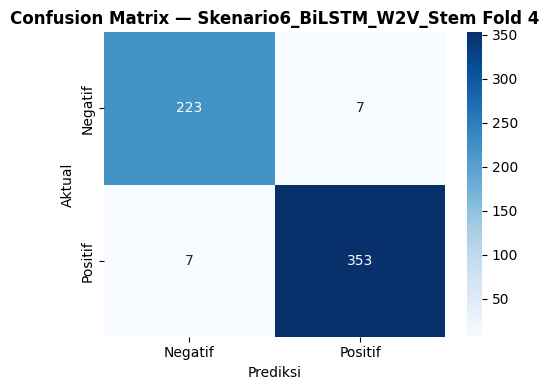

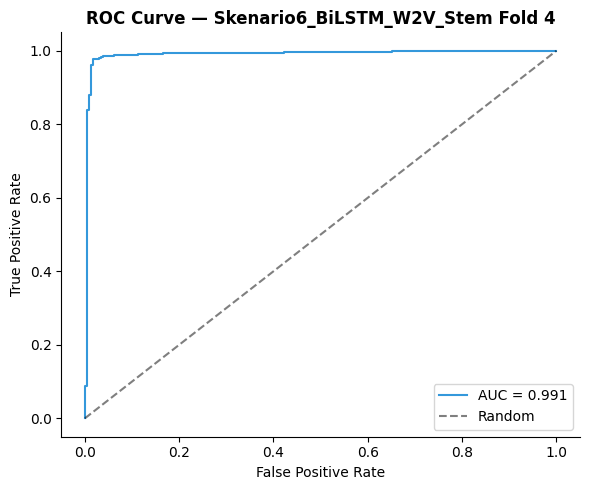


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 271ms/step - accuracy: 0.7435 - auc: 0.8323 - loss: 0.5615 - val_accuracy: 0.8814 - val_auc: 0.9550 - val_loss: 0.3383
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.8921 - auc: 0.9401 - loss: 0.3481 - val_accuracy: 0.9034 - val_auc: 0.9640 - val_loss: 0.2866
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.8997 - auc: 0.9527 - loss: 0.3063 - val_accuracy: 0.9102 - val_auc: 0.9679 - val_loss: 0.2600
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 248ms/step - accuracy: 0.9065 - auc: 0.9588 - loss: 0.2837 - val_accuracy: 0.9186 - val_auc: 0.9716 - val_loss: 0.2419
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 258ms/step - accuracy: 0.9107 - auc: 0.9634 - loss: 0.2646 - val_accuracy: 0.9237 - val_auc: 0.9749 - val_loss: 0.2259
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.9230 - auc: 0.9699 - loss: 0.2379 - val_accuracy: 0.9254 - val_auc: 0.97

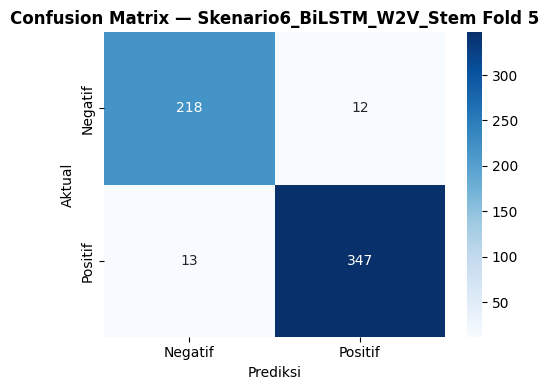

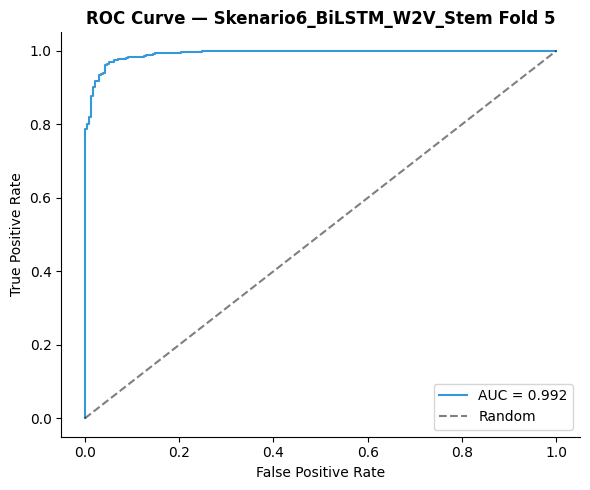


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario6_BiLSTM_W2V_Stem/model.h5


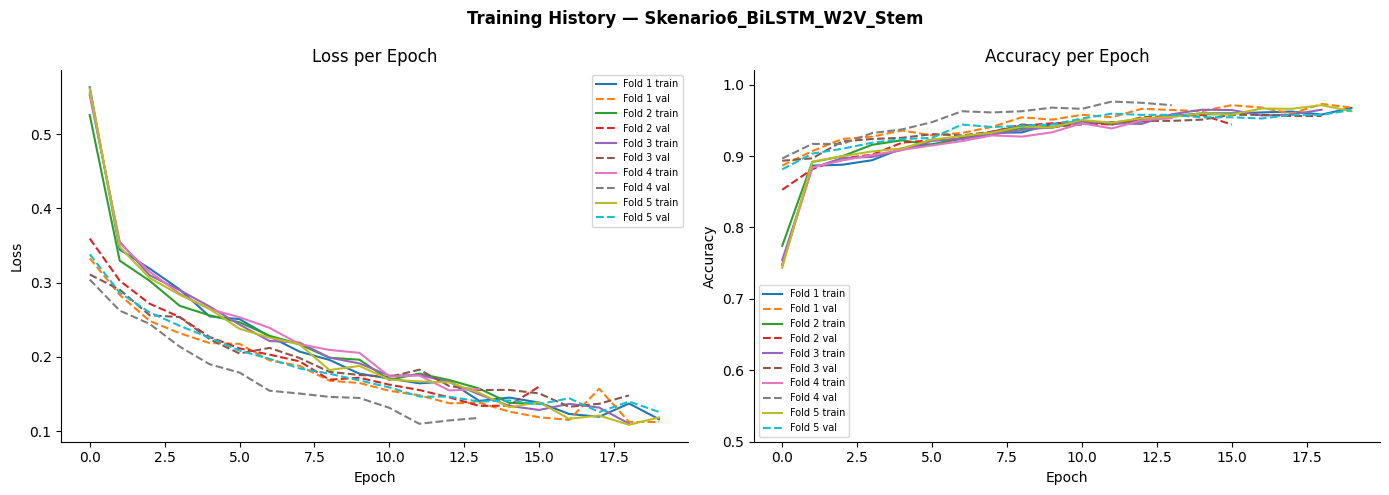


  ╔═ SELESAI: Skenario6_BiLSTM_W2V_Stem
  ║  avg Precision  : 0.9613 ± 0.0093
  ║  avg Recall     : 0.9613 ± 0.0094
  ║  avg F1 Macro   : 0.9612 ± 0.0092
  ║  avg Accuracy   : 0.9631 ± 0.0087
  ║  avg AUC        : 0.9912 ± 0.0012
  ║  avg RAM        : 3575.3 MB (27.6%)
  ║  avg CPU        : 13.0 %
  ║  avg Waktu      : 351.99 detik/fold
  ║  avg T/Epoch    : 19.69 detik/epoch
  ║  avg T/Step     : 0.2697 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 6 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[5])


  Training: Skenario7_BiLSTM_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 252ms/step - accuracy: 0.7515 - auc: 0.8328 - loss: 0.5673 - val_accuracy: 0.8629 - val_auc: 0.9596 - val_loss: 0.3811
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.8654 - auc: 0.9265 - loss: 0.3776 - val_accuracy: 0.9120 - val_auc: 0.9674 - val_loss: 0.2777
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.8810 - auc: 0.9389 - loss: 0.3416 - val_accuracy: 0.9272 - val_auc: 0.9698 - val_loss: 0.2578
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.8802 - auc: 0.9480 - loss: 0.3136 - val_accuracy: 0.9222 - val_auc: 0.9724 - val_loss: 0.2425
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 242ms/step - accuracy: 0.8908 - auc: 0.9537 - loss: 0.2936 - val_acc

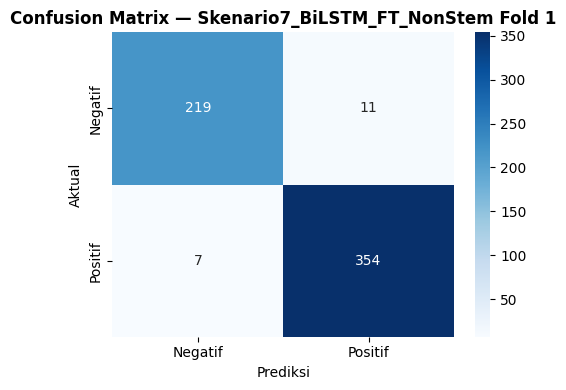

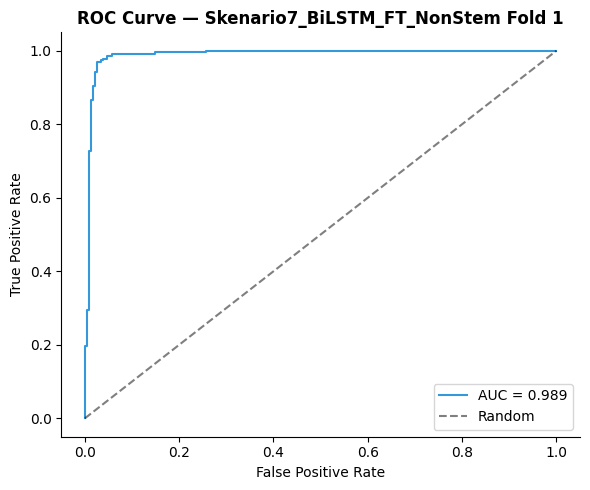


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 265ms/step - accuracy: 0.7248 - auc: 0.8075 - loss: 0.5901 - val_accuracy: 0.8342 - val_auc: 0.9226 - val_loss: 0.4221
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step - accuracy: 0.8730 - auc: 0.9319 - loss: 0.3654 - val_accuracy: 0.8545 - val_auc: 0.9416 - val_loss: 0.3770
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 269ms/step - accuracy: 0.8861 - auc: 0.9410 - loss: 0.3361 - val_accuracy: 0.8782 - val_auc: 0.9556 - val_loss: 0.3111
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.8920 - auc: 0.9512 - loss: 0.3059 - val_accuracy: 0.8849 - val_auc: 0.9648 - val_loss: 0.2863
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 250ms/step - accuracy: 0.8963 - auc: 0.9577 - loss: 0.2831 - val_accuracy: 0.8968 - val_auc: 0.9702 - val_loss: 0.2591
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 277ms/step - accuracy: 0.8997 - auc: 0.9590 - loss: 0.2753 - val_accuracy: 0.9086 - val_auc: 0.97

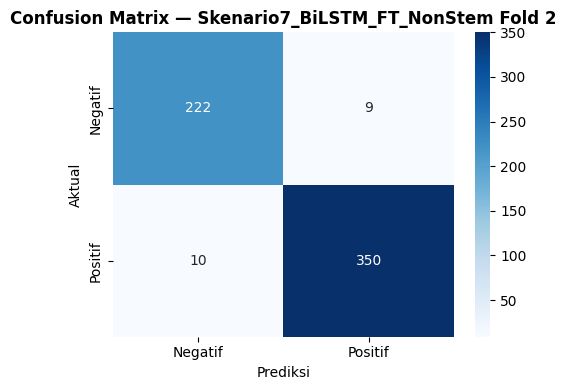

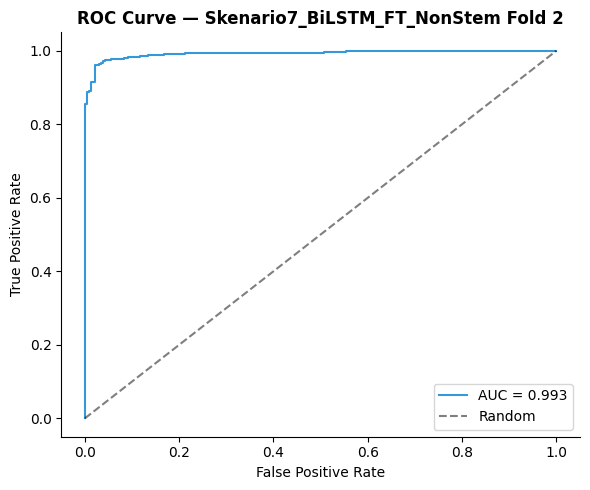


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.7549 - auc: 0.8312 - loss: 0.5640 - val_accuracy: 0.8832 - val_auc: 0.9569 - val_loss: 0.3286
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.8709 - auc: 0.9237 - loss: 0.3850 - val_accuracy: 0.9019 - val_auc: 0.9636 - val_loss: 0.2801
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.8857 - auc: 0.9446 - loss: 0.3261 - val_accuracy: 0.9086 - val_auc: 0.9677 - val_loss: 0.2674
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.8950 - auc: 0.9491 - loss: 0.3090 - val_accuracy: 0.9171 - val_auc: 0.9697 - val_loss: 0.2421
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 244ms/step - accuracy: 0.8954 - auc: 0.9559 - loss: 0.2903 - val_accuracy: 0.9188 - val_auc: 0.9746 - val_loss: 0.2239
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.9056 - auc: 0.9608 - loss: 0.2691 - val_accuracy: 0.9222 - val_auc: 0.97

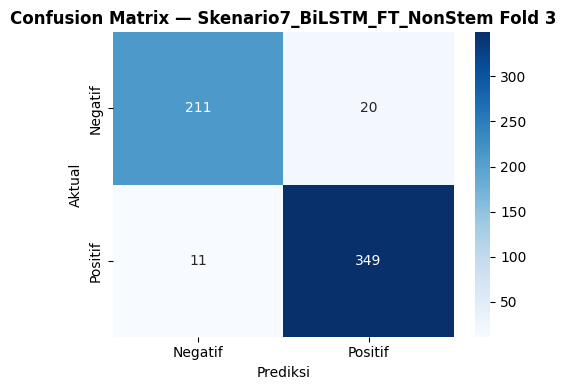

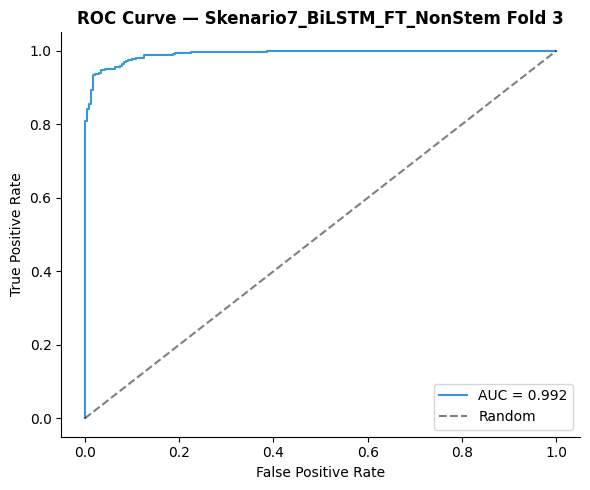


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - accuracy: 0.7626 - auc: 0.8373 - loss: 0.5585 - val_accuracy: 0.8864 - val_auc: 0.9577 - val_loss: 0.3278
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.8663 - auc: 0.9206 - loss: 0.3883 - val_accuracy: 0.8983 - val_auc: 0.9662 - val_loss: 0.2807
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.8722 - auc: 0.9363 - loss: 0.3476 - val_accuracy: 0.9034 - val_auc: 0.9691 - val_loss: 0.2659
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - accuracy: 0.8866 - auc: 0.9468 - loss: 0.3158 - val_accuracy: 0.9102 - val_auc: 0.9738 - val_loss: 0.2340
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.8891 - auc: 0.9557 - loss: 0.2882 - val_accuracy: 0.9203 - val_auc: 0.9786 - val_loss: 0.2086
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.8997 - auc: 0.9571 - loss: 0.2803 - val_accuracy: 0.9322 - val_auc: 0.98

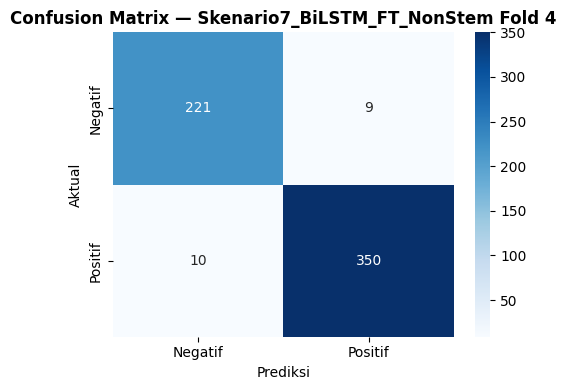

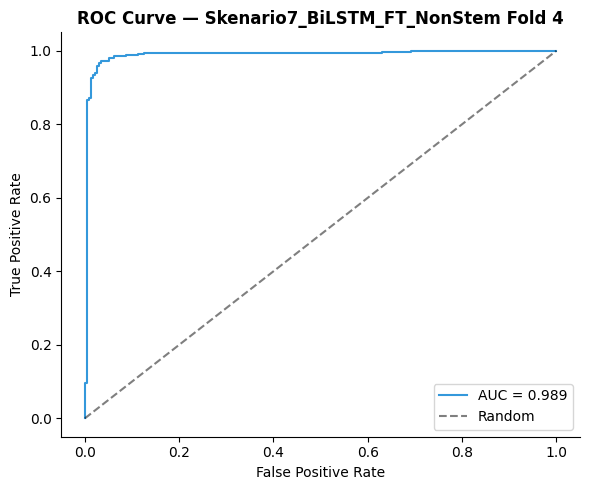


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 262ms/step - accuracy: 0.7224 - auc: 0.7959 - loss: 0.5947 - val_accuracy: 0.8729 - val_auc: 0.9454 - val_loss: 0.3662
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.8616 - auc: 0.9214 - loss: 0.3920 - val_accuracy: 0.8966 - val_auc: 0.9558 - val_loss: 0.3174
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.8836 - auc: 0.9434 - loss: 0.3312 - val_accuracy: 0.8983 - val_auc: 0.9613 - val_loss: 0.2897
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - accuracy: 0.8925 - auc: 0.9504 - loss: 0.3077 - val_accuracy: 0.9068 - val_auc: 0.9655 - val_loss: 0.2741
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.8984 - auc: 0.9565 - loss: 0.2852 - val_accuracy: 0.9119 - val_auc: 0.9710 - val_loss: 0.2611
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.9048 - auc: 0.9571 - loss: 0.2781 - val_accuracy: 0.8983 - val_auc: 0.97

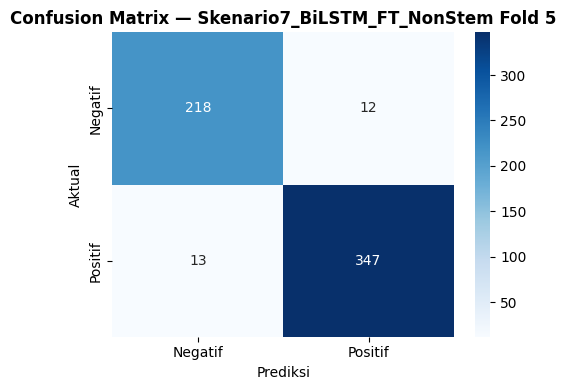

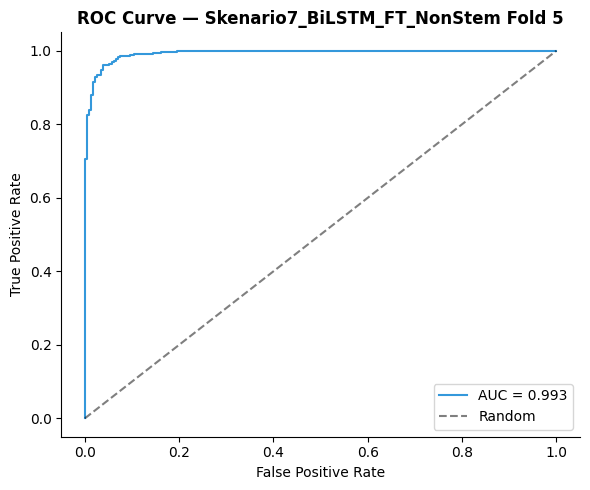


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario7_BiLSTM_FT_NonStem/model.h5


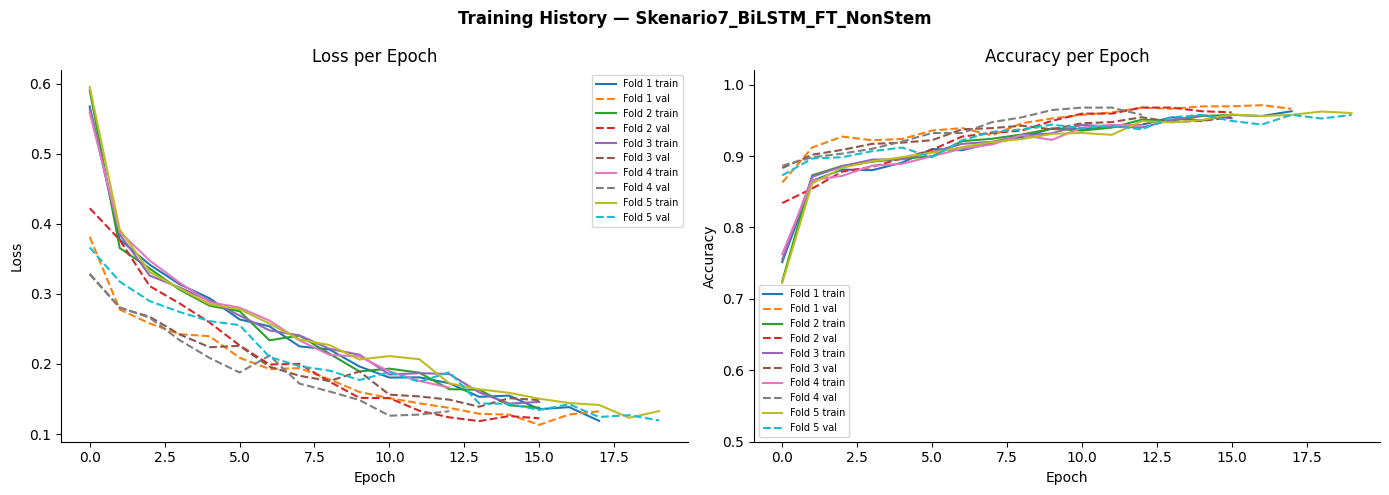


  ╔═ SELESAI: Skenario7_BiLSTM_FT_NonStem
  ║  avg Precision  : 0.9609 ± 0.0089
  ║  avg Recall     : 0.9594 ± 0.0110
  ║  avg F1 Macro   : 0.9601 ± 0.0100
  ║  avg Accuracy   : 0.9621 ± 0.0094
  ║  avg AUC        : 0.9912 ± 0.0019
  ║  avg RAM        : 3930.8 MB (30.3%)
  ║  avg CPU        : 13.0 %
  ║  avg Waktu      : 335.84 detik/fold
  ║  avg T/Epoch    : 20.14 detik/epoch
  ║  avg T/Step     : 0.2759 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 7 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[6])


  Training: Skenario8_BiLSTM_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1440, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - accuracy: 0.7146 - auc: 0.7811 - loss: 0.6083 - val_accuracy: 0.8866 - val_auc: 0.9568 - val_loss: 0.3555
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.8637 - auc: 0.9198 - loss: 0.3920 - val_accuracy: 0.8849 - val_auc: 0.9618 - val_loss: 0.3339
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.8789 - auc: 0.9389 - loss: 0.3418 - val_accuracy: 0.9052 - val_auc: 0.9683 - val_loss: 0.2806
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.8984 - auc: 0.9526 - loss: 0.3000 - val_accuracy: 0.9222 - val_auc: 0.9721 - val_loss: 0.2544
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.8992 - auc: 0.9559 - loss: 0.2867 - val_accura

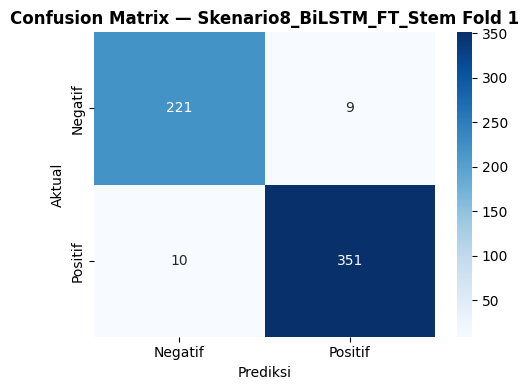

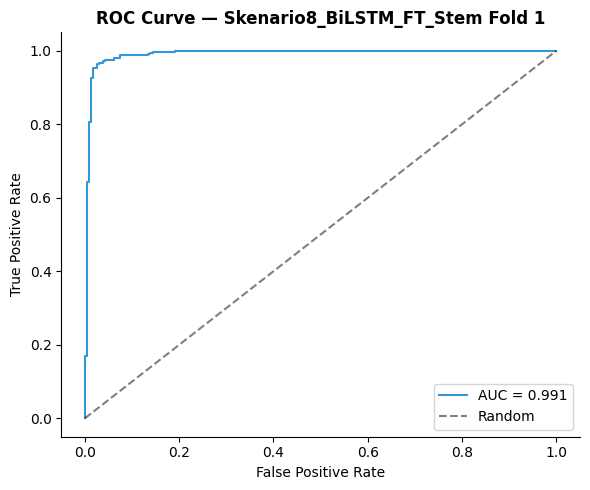


  ── Fold 2/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 268ms/step - accuracy: 0.7485 - auc: 0.8288 - loss: 0.5616 - val_accuracy: 0.8409 - val_auc: 0.9239 - val_loss: 0.4170
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - accuracy: 0.8726 - auc: 0.9260 - loss: 0.3791 - val_accuracy: 0.8680 - val_auc: 0.9502 - val_loss: 0.3251
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.8798 - auc: 0.9433 - loss: 0.3306 - val_accuracy: 0.8782 - val_auc: 0.9587 - val_loss: 0.2940
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.8853 - auc: 0.9499 - loss: 0.3076 - val_accuracy: 0.8832 - val_auc: 0.9636 - val_loss: 0.2794
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.8967 - auc: 0.9537 - loss: 0.2944 - val_accuracy: 0.8934 - val_auc: 0.9680 - val_loss: 0.2521
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.9064 - auc: 0.9590 - loss: 0.2739 - val_accuracy: 0.9103 - val_auc: 0.97

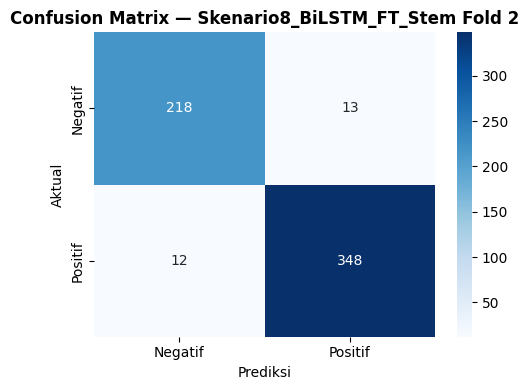

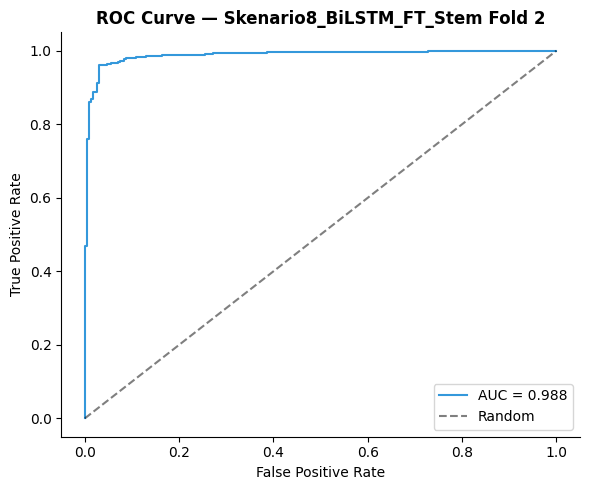


  ── Fold 3/5 ──
  Distribusi train: Pos=1441, Neg=921
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 255ms/step - accuracy: 0.7659 - auc: 0.8423 - loss: 0.5480 - val_accuracy: 0.8765 - val_auc: 0.9547 - val_loss: 0.3328
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.8624 - auc: 0.9248 - loss: 0.3814 - val_accuracy: 0.8849 - val_auc: 0.9586 - val_loss: 0.3117
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 276ms/step - accuracy: 0.8776 - auc: 0.9361 - loss: 0.3447 - val_accuracy: 0.9069 - val_auc: 0.9652 - val_loss: 0.2646
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 248ms/step - accuracy: 0.8806 - auc: 0.9445 - loss: 0.3192 - val_accuracy: 0.9086 - val_auc: 0.9712 - val_loss: 0.2447
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9005 - auc: 0.9557 - loss: 0.2885 - val_accuracy: 0.9188 - val_auc: 0.9744 - val_loss: 0.2308
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.9035 - auc: 0.9625 - loss: 0.2618 - val_accuracy: 0.9120 - val_auc: 0.97

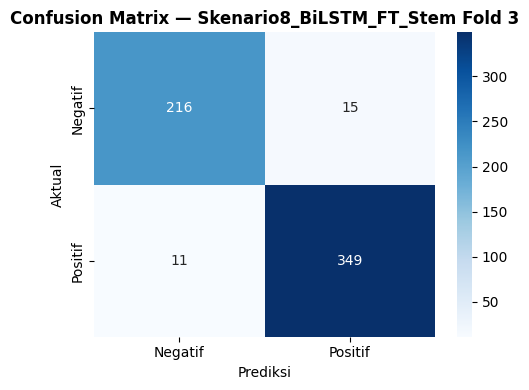

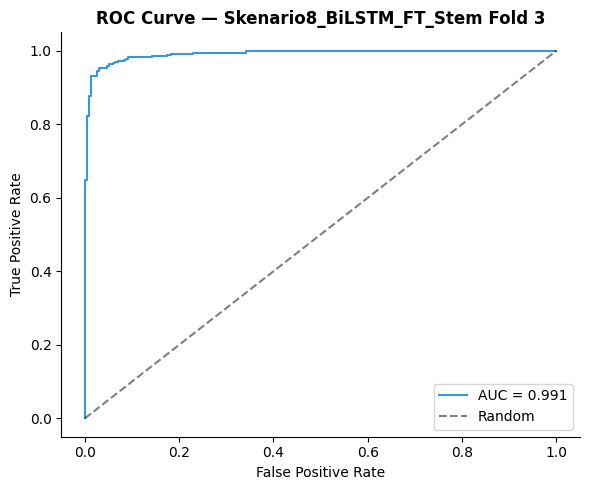


  ── Fold 4/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 262ms/step - accuracy: 0.6923 - auc: 0.7618 - loss: 0.6305 - val_accuracy: 0.8763 - val_auc: 0.9548 - val_loss: 0.3471
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.8603 - auc: 0.9167 - loss: 0.3980 - val_accuracy: 0.9017 - val_auc: 0.9685 - val_loss: 0.2770
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.8739 - auc: 0.9344 - loss: 0.3548 - val_accuracy: 0.9068 - val_auc: 0.9701 - val_loss: 0.2565
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step - accuracy: 0.8870 - auc: 0.9425 - loss: 0.3305 - val_accuracy: 0.9102 - val_auc: 0.9749 - val_loss: 0.2457
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 266ms/step - accuracy: 0.8963 - auc: 0.9514 - loss: 0.3014 - val_accuracy: 0.9288 - val_auc: 0.9785 - val_loss: 0.2107
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.8934 - auc: 0.9514 - loss: 0.2981 - val_accuracy: 0.9288 - val_auc: 0.97

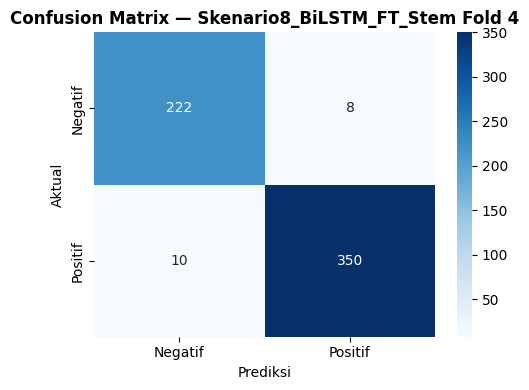

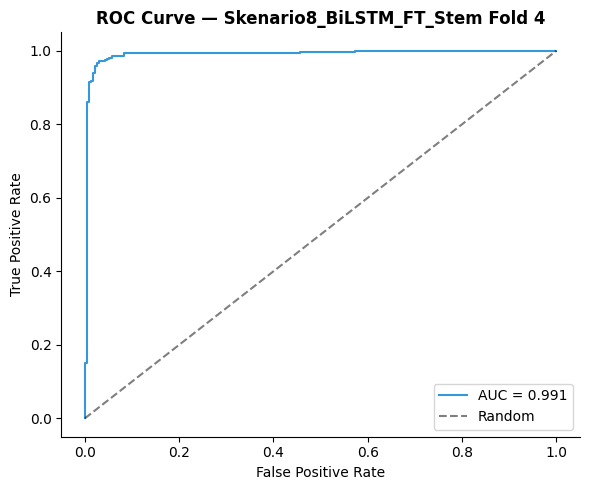


  ── Fold 5/5 ──
  Distribusi train: Pos=1441, Neg=922
Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 256ms/step - accuracy: 0.7355 - auc: 0.8193 - loss: 0.5793 - val_accuracy: 0.8661 - val_auc: 0.9430 - val_loss: 0.3859
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.8642 - auc: 0.9249 - loss: 0.3878 - val_accuracy: 0.8847 - val_auc: 0.9549 - val_loss: 0.3244
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.8811 - auc: 0.9366 - loss: 0.3487 - val_accuracy: 0.9017 - val_auc: 0.9607 - val_loss: 0.2991
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.8840 - auc: 0.9447 - loss: 0.3267 - val_accuracy: 0.9051 - val_auc: 0.9649 - val_loss: 0.2702
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.8925 - auc: 0.9532 - loss: 0.2968 - val_accuracy: 0.9051 - val_auc: 0.9698 - val_loss: 0.2520
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.8967 - auc: 0.9559 - loss: 0.2859 - val_accuracy: 0.9203 - val_auc: 0.97

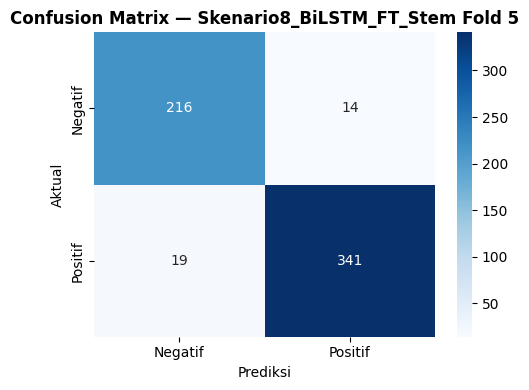

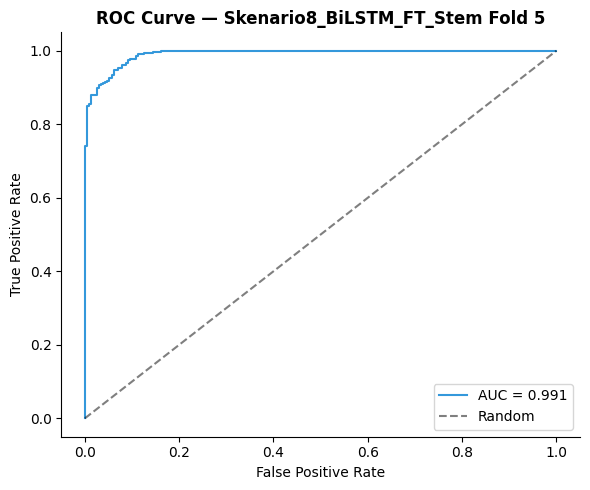


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario8_BiLSTM_FT_Stem/model.h5


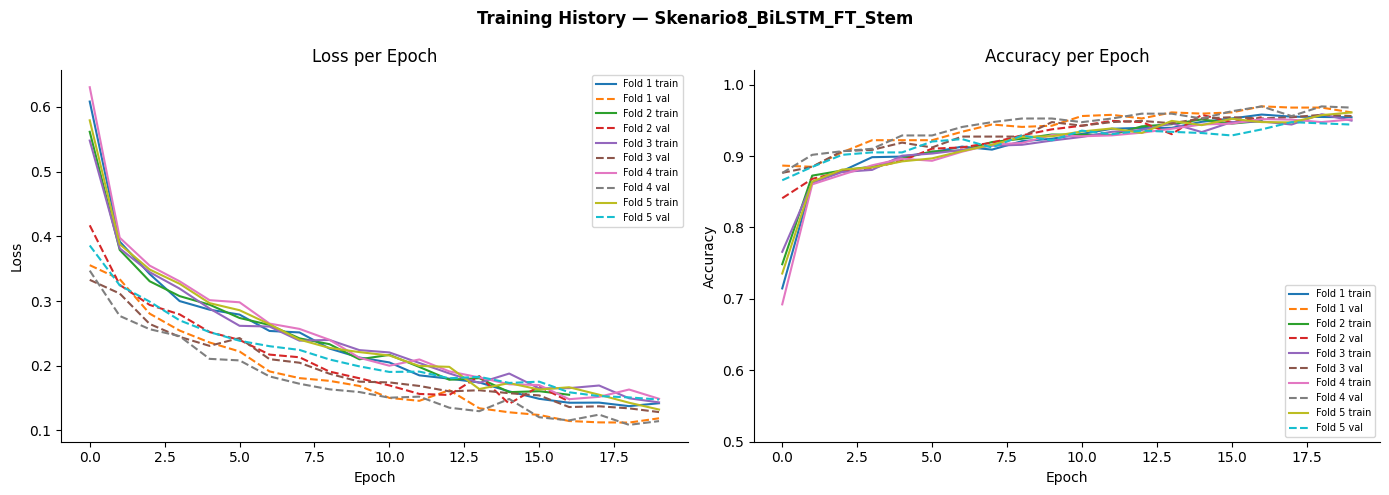


  ╔═ SELESAI: Skenario8_BiLSTM_FT_Stem
  ║  avg Precision  : 0.9568 ± 0.0110
  ║  avg Recall     : 0.9572 ± 0.0106
  ║  avg F1 Macro   : 0.9570 ± 0.0107
  ║  avg Accuracy   : 0.9590 ± 0.0103
  ║  avg AUC        : 0.9906 ± 0.0013
  ║  avg RAM        : 4177.4 MB (32.2%)
  ║  avg CPU        : 27.8 %
  ║  avg Waktu      : 388.99 detik/fold
  ║  avg T/Epoch    : 20.02 detik/epoch
  ║  avg T/Step     : 0.2742 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 8 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[7])

## 8. Rekap Hasil & Simpan ke Excel


In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task3_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)

print('=== Rekap Semua Skenario (urut F1 Macro) ===')
cols_tampil = ['skenario', 'avg_f1_macro', 'std_f1_macro',
               'avg_accuracy', 'avg_precision_macro',
               'avg_recall_macro', 'avg_auc']
print(df_rekap[cols_tampil].to_string(index=False))

# Simpan ke Excel
excel_path = OUTPUT_DIR + 'rekap_Task3_semua_skenario.xlsx'
df_rekap.to_excel(excel_path, index=False)
print(f'\nDisimpan ke: {excel_path}')

=== Rekap Semua Skenario (urut F1 Macro) ===
                    skenario  avg_f1_macro  std_f1_macro  avg_accuracy  avg_precision_macro  avg_recall_macro  avg_auc
Skenario5_BiLSTM_W2V_NonStem        0.9656        0.0071        0.9672               0.9640            0.9676   0.9918
      Skenario2_CNN_W2V_Stem        0.9644        0.0072        0.9661               0.9642            0.9647   0.9917
   Skenario1_CNN_W2V_NonStem        0.9623        0.0120        0.9641               0.9624            0.9621   0.9917
   Skenario6_BiLSTM_W2V_Stem        0.9612        0.0092        0.9631               0.9613            0.9613   0.9912
 Skenario7_BiLSTM_FT_NonStem        0.9601        0.0100        0.9621               0.9609            0.9594   0.9912
    Skenario3_CNN_FT_NonStem        0.9598        0.0078        0.9617               0.9595            0.9605   0.9910
       Skenario4_CNN_FT_Stem        0.9573        0.0120        0.9594               0.9580            0.9575   0.9897
   

In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task3_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

print('='*100)
print('  REKAP SEMUA SKENARIO TASK 3 — SENTIMEN HOTEL')
print('  Diurutkan berdasarkan F1 Macro Tertinggi')
print('='*100)

# Tampilkan per kelompok metrik
cols_utama = ['rank', 'skenario',
              'avg_f1_macro', 'std_f1_macro',
              'avg_precision_macro', 'std_precision_macro',
              'avg_recall_macro', 'std_recall_macro',
              'avg_accuracy', 'std_accuracy',
              'avg_auc', 'std_auc']

cols_resource = ['rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_time_per_epoch',  'std_time_per_epoch',
    'avg_time_per_step',   'std_time_per_step',
    'avg_ram_mb',          'std_ram_mb',
    'avg_ram_pct',         'std_ram_pct',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti']

# Filter kolom yang ada saja
cols_utama    = [c for c in cols_utama    if c in df_rekap.columns]
cols_resource = [c for c in cols_resource if c in df_rekap.columns]

print('\n── Metrik Performa ──')
print(df_rekap[cols_utama].to_string(index=False))

print('\n── Resource Usage ──')
print(df_rekap[cols_resource].to_string(index=False))

# Highlight model terbaik
best = df_rekap.iloc[0]
print('\n' + '='*100)
print(f'     MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC          : {best["avg_auc"]:.4f} ± {best["std_auc"]:.4f}')
print('='*100)

# Simpan ke Excel dengan formatting
excel_path = OUTPUT_DIR + 'rekap_Task3_semua_skenario.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Semua metrik
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)

    # Sheet 2: Ringkasan
    cols_ringkasan = [c for c in [
        'rank', 'skenario',
        'avg_f1_macro', 'std_f1_macro',
        'avg_precision_macro', 'avg_recall_macro',
        'avg_accuracy', 'avg_auc',
        'avg_waktu_training', 'avg_ram_mb'
    ] if c in df_rekap.columns]

    df_rekap[cols_ringkasan].to_excel(
        writer, sheet_name='Ringkasan', index=False
    )

print(f'\n✅ Disimpan ke : {excel_path}')

  REKAP SEMUA SKENARIO TASK 3 — SENTIMEN HOTEL
  Diurutkan berdasarkan F1 Macro Tertinggi

── Metrik Performa ──
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc  std_auc
    1 Skenario5_BiLSTM_W2V_NonStem        0.9656        0.0071               0.9640               0.0072            0.9676            0.0077        0.9672        0.0068   0.9918   0.0029
    2       Skenario2_CNN_W2V_Stem        0.9644        0.0072               0.9642               0.0071            0.9647            0.0075        0.9661        0.0069   0.9917   0.0015
    3    Skenario1_CNN_W2V_NonStem        0.9623        0.0120               0.9624               0.0124            0.9621            0.0117        0.9641        0.0115   0.9917   0.0023
    4    Skenario6_BiLSTM_W2V_Stem        0.9612        0.0092               0.9613               0.0093            0.9613            0.009


Plot: Skenario1_CNN_W2V_NonStem


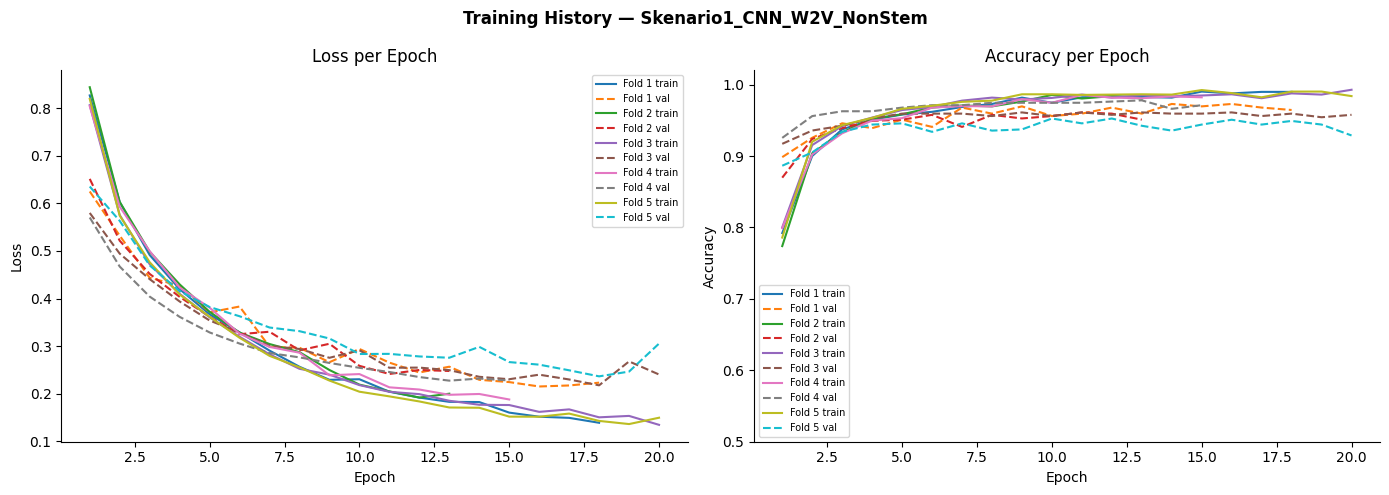

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario1_CNN_W2V_NonStem/training_history_accuracy.png

Plot: Skenario2_CNN_W2V_Stem


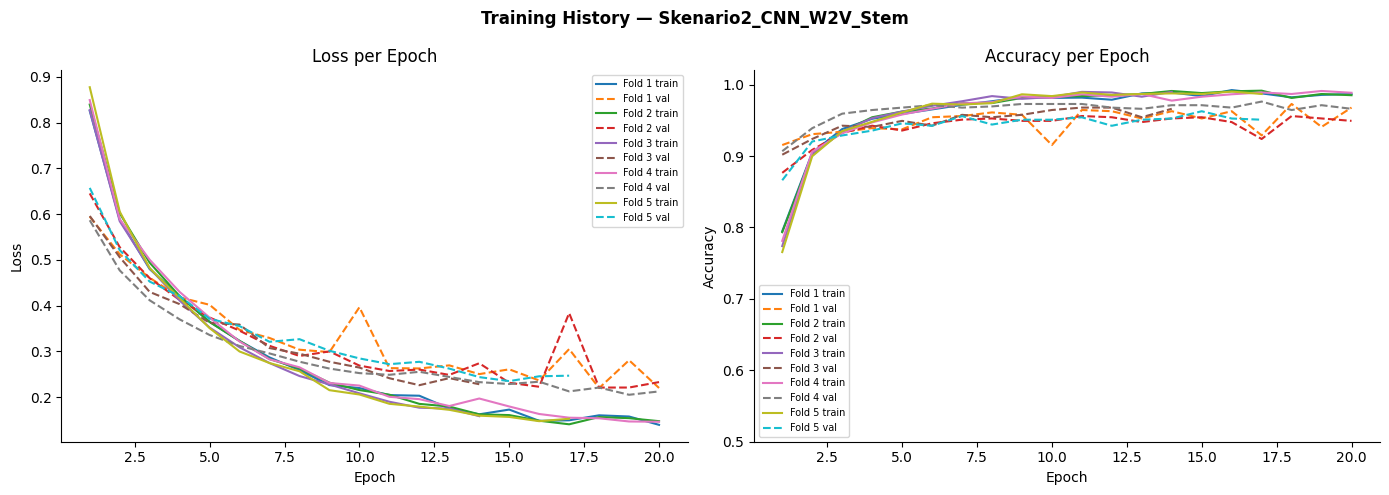

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario2_CNN_W2V_Stem/training_history_accuracy.png

Plot: Skenario3_CNN_FT_NonStem


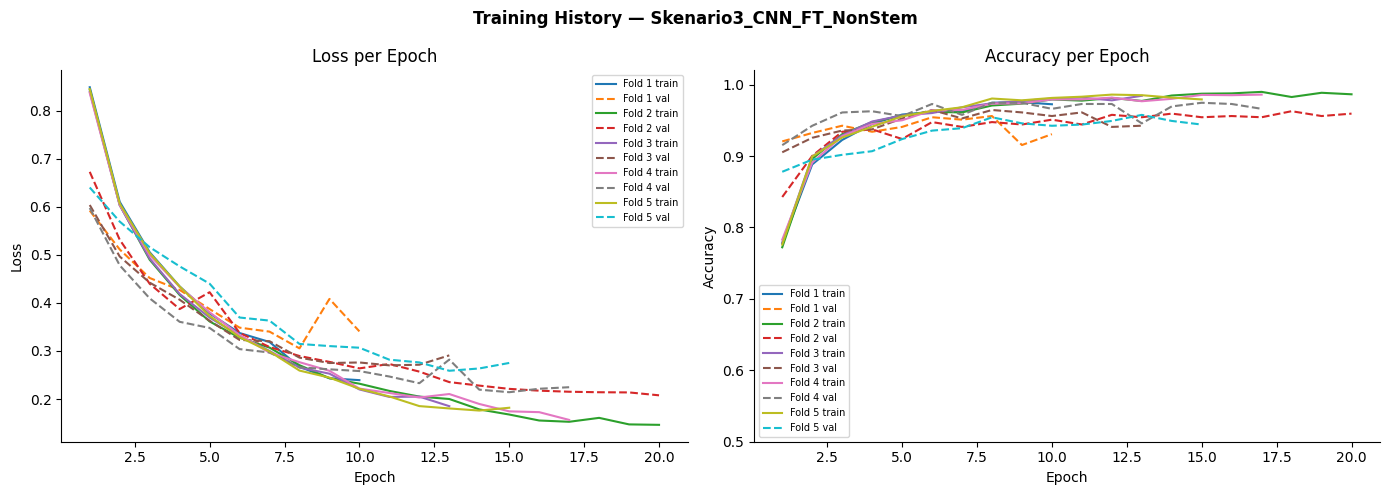

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario3_CNN_FT_NonStem/training_history_accuracy.png

Plot: Skenario4_CNN_FT_Stem


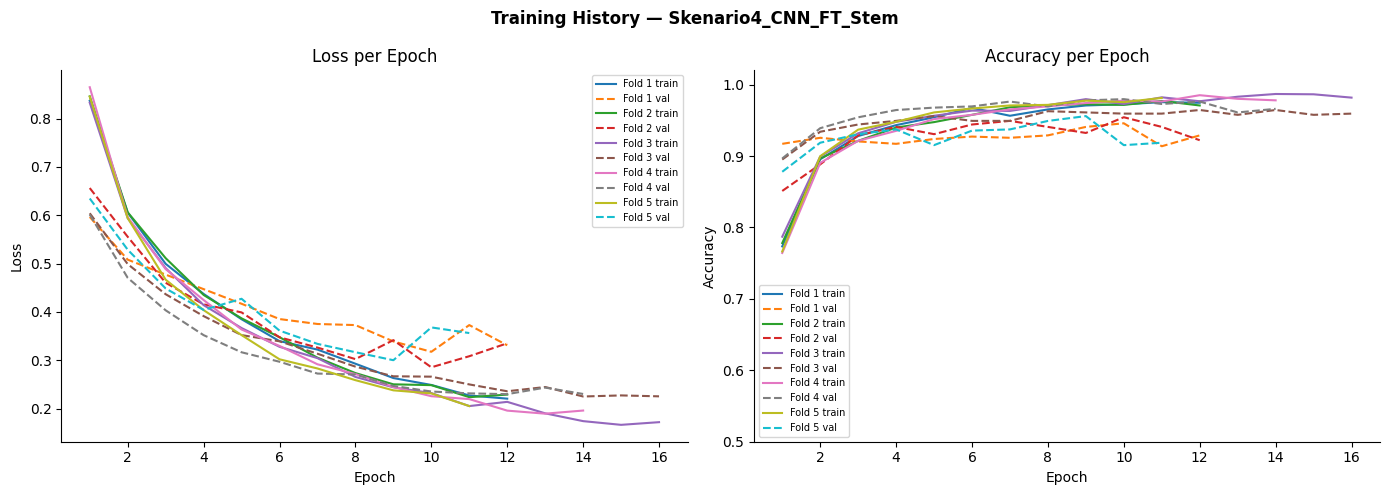

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario4_CNN_FT_Stem/training_history_accuracy.png

Plot: Skenario5_BiLSTM_W2V_NonStem


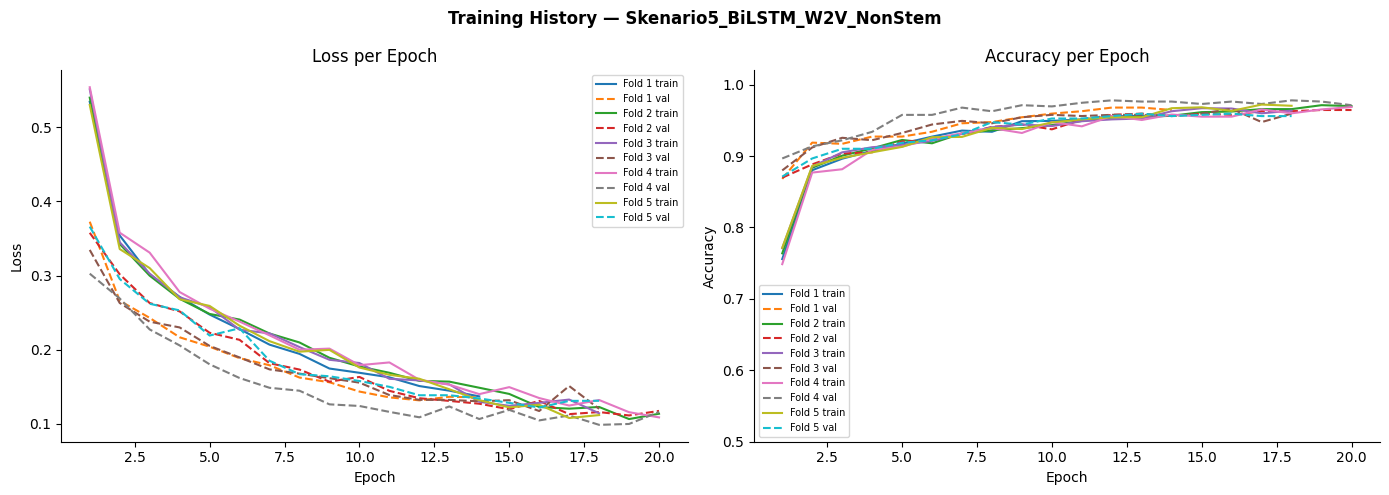

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario5_BiLSTM_W2V_NonStem/training_history_accuracy.png

Plot: Skenario6_BiLSTM_W2V_Stem


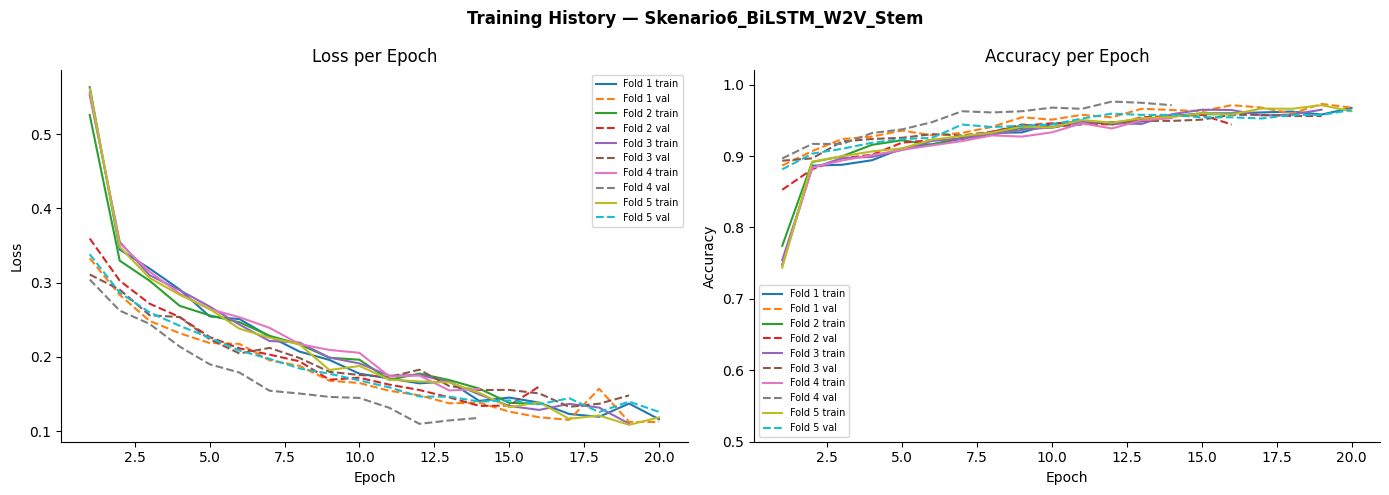

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario6_BiLSTM_W2V_Stem/training_history_accuracy.png

Plot: Skenario7_BiLSTM_FT_NonStem


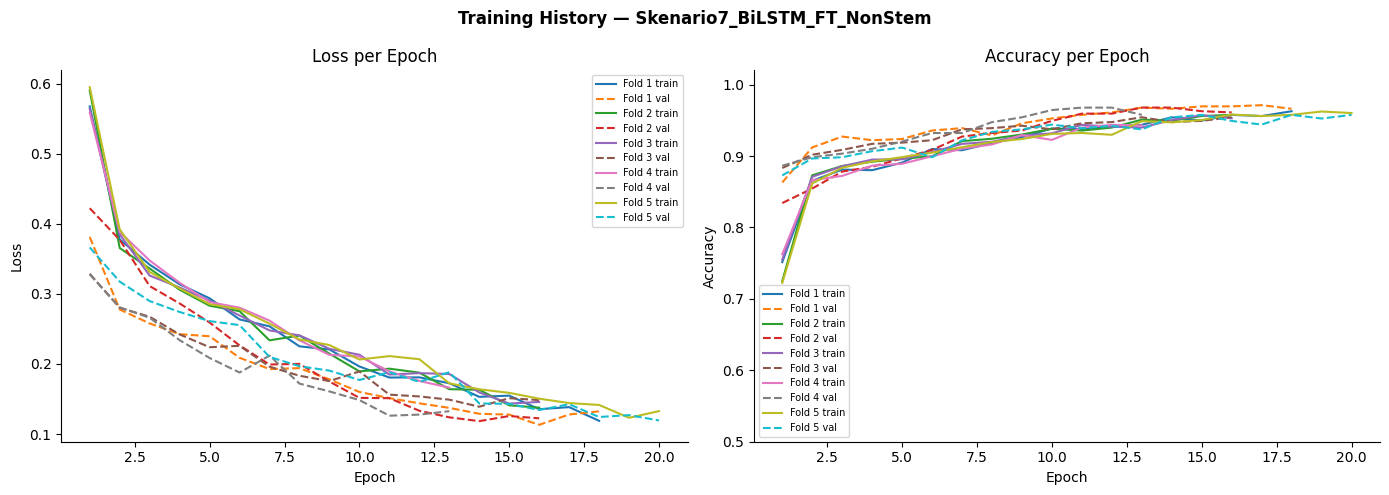

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario7_BiLSTM_FT_NonStem/training_history_accuracy.png

Plot: Skenario8_BiLSTM_FT_Stem


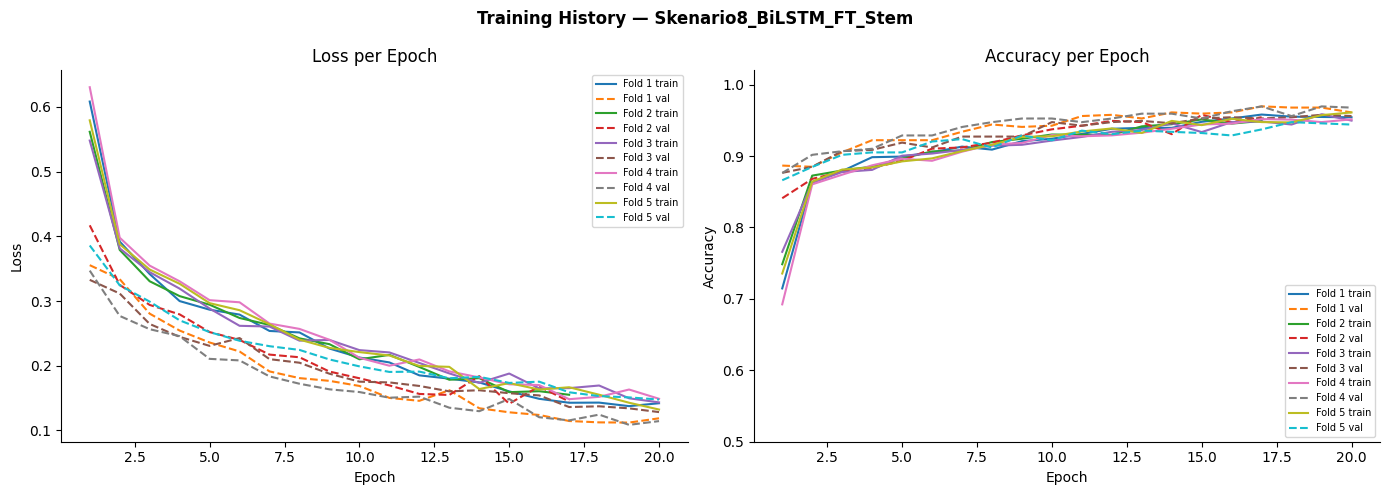

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task3_Hotel/Skenario8_BiLSTM_FT_Stem/training_history_accuracy.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ulang_dari_csv(skenario_dir, nama_skenario):
    # Load history CSV
    df = pd.read_csv(skenario_dir + 'history_per_fold.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_ke in sorted(df['fold'].unique()):
        df_fold = df[df['fold'] == fold_ke]
        label   = f'Fold {fold_ke}'

        # Loss
        axes[0].plot(df_fold['epoch'], df_fold['loss'],
                     linestyle='-',  label=f'{label} train')
        axes[0].plot(df_fold['epoch'], df_fold['val_loss'],
                     linestyle='--', label=f'{label} val')

        # Accuracy
        axes[1].plot(df_fold['epoch'], df_fold['accuracy'],
                     linestyle='-',  label=f'{label} train')
        axes[1].plot(df_fold['epoch'], df_fold['val_accuracy'],
                     linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()

    # Simpan
    output_path = skenario_dir + 'training_history_accuracy.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✅ Disimpan: {output_path}')


# ── Jalankan untuk semua skenario Task 3 ──
BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
TASK3_DIR   = BASE_DIR + 'Dataset/Dataset_Modelling/Task3_Hotel/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

for nama in skenario_list:
    path = TASK3_DIR + nama + '/'
    csv  = path + 'history_per_fold.csv'
    if os.path.exists(csv):
        print(f'\nPlot: {nama}')
        plot_ulang_dari_csv(path, nama)
    else:
        print(f'Skip {nama} — belum ada CSV')

## 9. Rekomendasi Model Terbaik


In [ ]:
# Model terbaik = F1 Macro tertinggi
model_terbaik = df_rekap.iloc[0]
print('=== Model Terbaik Task 3 ===')
print(f"Skenario    : {model_terbaik['skenario']}")
print(f"avg F1 Macro: {model_terbaik['avg_f1_macro']:.4f} ± {model_terbaik['std_f1_macro']:.4f}")
print(f"avg Accuracy: {model_terbaik['avg_accuracy']:.4f}")
print(f"avg AUC     : {model_terbaik['avg_auc']:.4f}")


=== Model Terbaik Task 3 ===
Skenario    : Skenario5_BiLSTM_W2V_NonStem
avg F1 Macro: 0.9656 ± 0.0071
avg Accuracy: 0.9672
avg AUC     : 0.9918


## 10. Visualisasi Perbandingan Semua Skenario


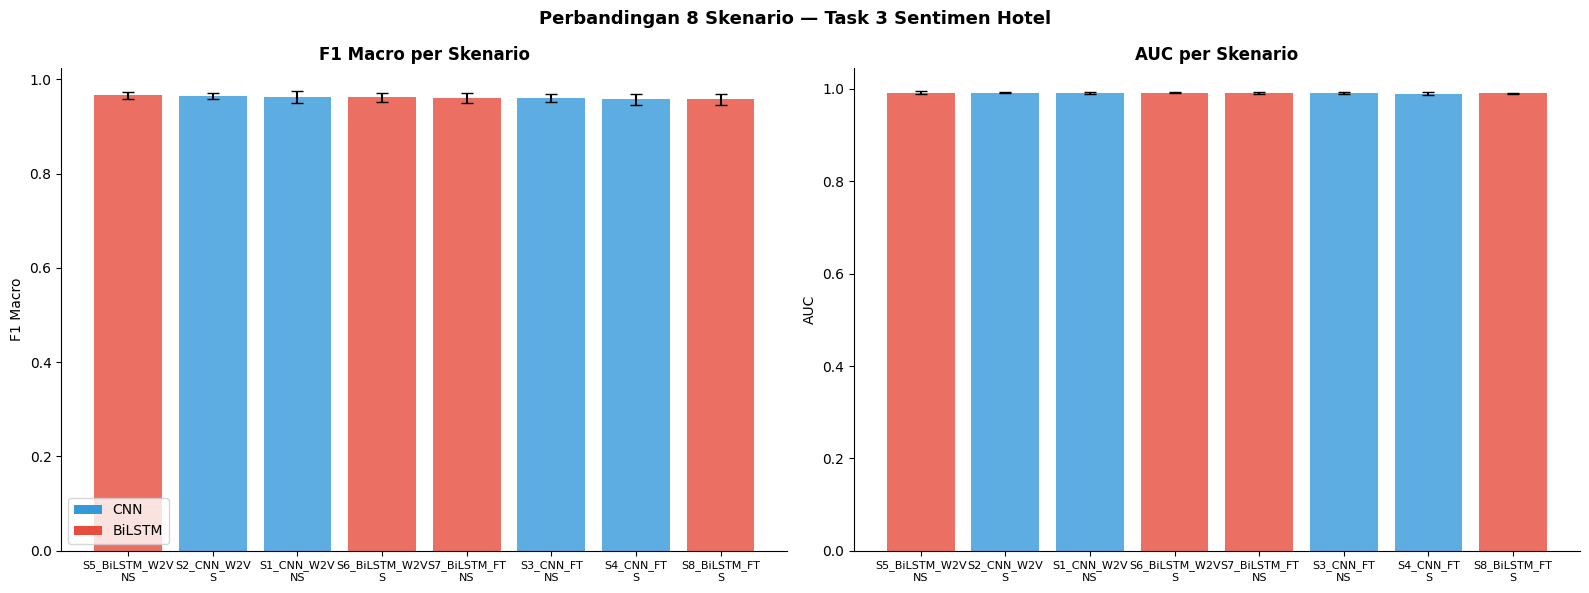

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db' if 'CNN' in s else '#e74c3c'
          for s in df_rekap['skenario']]
labels_short = [s.replace('Skenario','S').replace('_NonStem','\nNS').replace('_Stem','\nS')
                for s in df_rekap['skenario']]

# F1 Macro
bars = axes[0].bar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                   color=colors, alpha=0.8)
axes[0].errorbar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                 yerr=df_rekap['std_f1_macro'], fmt='none',
                 color='black', capsize=4)
axes[0].set_xticks(range(len(df_rekap)))
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_title('F1 Macro per Skenario', fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].spines[['top','right']].set_visible(False)

# AUC
axes[1].bar(range(len(df_rekap)), df_rekap['avg_auc'],
            color=colors, alpha=0.8)
axes[1].errorbar(range(len(df_rekap)), df_rekap['avg_auc'],
                 yerr=df_rekap['std_auc'], fmt='none',
                 color='black', capsize=4)
axes[1].set_xticks(range(len(df_rekap)))
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].set_title('AUC per Skenario', fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#e74c3c', label='BiLSTM')
]
axes[0].legend(handles=legend_elements)

plt.suptitle('Perbandingan 8 Skenario — Task 3 Sentimen Hotel',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'perbandingan_skenario_Task3.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

# ============================================================
# DUMMY CLASSIFIER BASELINE — Task 3 Sentimen Hotel
# (LABEL_COL sesuai task masing-masing)
# ============================================================

print('='*60)
print('  DUMMY CLASSIFIER BASELINE')
print('  Strategi: majority class (tebak kelas terbanyak)')
print('='*60)

# Data train dan test sudah ada dari cell sebelumnya
# y_train = label training
# y_test  = label test (load dulu kalau belum)

# Kalau y_test belum ada, load dulu:
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task3_Hotel.csv')
y_test   = df_test[LABEL_COL].values

print(f'\n  Distribusi data train:')
print(f'  Positif : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')

print(f'\n  Distribusi data test:')
print(f'  Positif : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

# Strategi 1: most_frequent (tebak majority class)
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(y_train.reshape(-1,1), y_train)
y_pred_majority = dummy_majority.predict(y_test.reshape(-1,1))

# Strategi 2: stratified (tebak random sesuai proporsi)
dummy_stratified = DummyClassifier(strategy='stratified',
                                    random_state=42)
dummy_stratified.fit(y_train.reshape(-1,1), y_train)
y_pred_stratified = dummy_stratified.predict(y_test.reshape(-1,1))

# Hitung F1
f1_majority   = f1_score(y_test, y_pred_majority,
                          average='macro', zero_division=0)
f1_stratified = f1_score(y_test, y_pred_stratified,
                          average='macro', zero_division=0)

print(f'\n  Hasil Dummy Classifier:')
print(f'  {"Strategi":<20} {"F1 Macro":>10}')
print(f'  {"-"*32}')
print(f'  {"Most Frequent":<20} {f1_majority:>10.4f}')
print(f'  {"Stratified":<20} {f1_stratified:>10.4f}')

print(f'\n  Classification Report — Most Frequent:')
print(classification_report(
    y_test, y_pred_majority,
    target_names=['Negatif', 'Positif'],
    zero_division=0
))

print('='*60)
print('  PERBANDINGAN MODEL vs DUMMY')
print('='*60)

# Ambil F1 terbaik dari rekap kalau sudah ada
try:
    df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task3_semua_skenario.csv')
    best_f1  = df_rekap['avg_f1_macro'].max()
    best_sk  = df_rekap.loc[df_rekap['avg_f1_macro'].idxmax(), 'skenario']
    print(f'  Model terbaik : {best_sk}')
    print(f'  F1 model      : {best_f1:.4f}')
    print(f'  F1 dummy      : {f1_majority:.4f}')
    print(f'  Selisih       : +{best_f1 - f1_majority:.4f}')
    print(f'\n  → Model {((best_f1/max(f1_majority,0.0001))-1)*100:.0f}% '
          f'lebih baik dari dummy!')
except:
    print(f'  F1 dummy (majority)   : {f1_majority:.4f}')
    print(f'  F1 dummy (stratified) : {f1_stratified:.4f}')
    print(f'  → Bandingkan dengan F1 model setelah training selesai')

print('='*60)

  DUMMY CLASSIFIER BASELINE
  Strategi: majority class (tebak kelas terbanyak)

  Distribusi data train:
  Positif : 1801 (61.0%)
  Negatif : 1152 (39.0%)

  Distribusi data test:
  Positif : 200 (61.0%)
  Negatif : 128 (39.0%)

  Hasil Dummy Classifier:
  Strategi               F1 Macro
  --------------------------------
  Most Frequent            0.3788
  Stratified               0.5183

  Classification Report — Most Frequent:
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       128
     Positif       0.61      1.00      0.76       200

    accuracy                           0.61       328
   macro avg       0.30      0.50      0.38       328
weighted avg       0.37      0.61      0.46       328

  PERBANDINGAN MODEL vs DUMMY
  Model terbaik : Skenario5_BiLSTM_W2V_NonStem
  F1 model      : 0.9656
  F1 dummy      : 0.3788
  Selisih       : +0.5868

  → Model 155% lebih baik dari dummy!
